In [1]:
!pip install keras-tuner --upgrade


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Phase-1 Data Understanding

In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\SURYA\tfenv\Scripts\python.exe -m pip install --upgrade pip


In [3]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\SURYA\tfenv\Scripts\python.exe -m pip install --upgrade pip


In [4]:
import tensorflow as tf
import pandas as pd

print("TensorFlow:", tf.__version__)
print("Pandas:", pd.__version__)

TensorFlow: 2.21.0
Pandas: 2.3.2


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [6]:
# load data
data = pd.read_csv("dataset/HAM10000_metadata.csv")

In [7]:
data.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [8]:
print("Rows :", data.shape[0])
print("Columns :", data.shape[1])

Rows : 10015
Columns : 7


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [10]:
# missing value
data.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [11]:
data.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')

In [12]:
#target classes
data["dx"].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

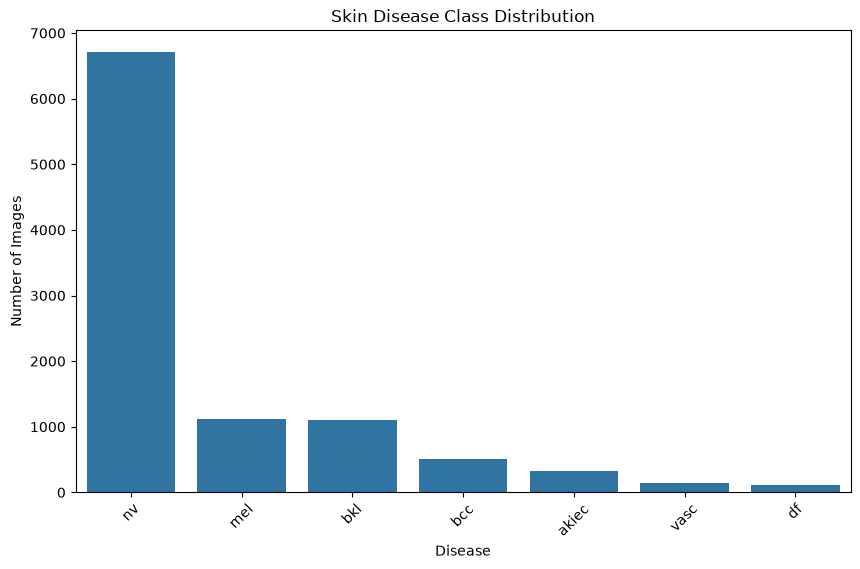

In [13]:
plt.figure(figsize=(10,6))
sns.countplot(data=data, x="dx", order=data["dx"].value_counts().index)
plt.title("Skin Disease Class Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

In [14]:
# class percentage
class_percentage = (data["dx"].value_counts(normalize=True)*100)
print(class_percentage)

dx
nv       66.949576
mel      11.113330
bkl      10.973540
bcc       5.132302
akiec     3.265102
vasc      1.417873
df        1.148278
Name: proportion, dtype: float64


In [15]:
# class imbalance
print("Largest Class")
print(data["dx"].value_counts().idxmax())

print()

print("Smallest Class")
print(data["dx"].value_counts().idxmin())

Largest Class
nv

Smallest Class
df


In [16]:
import os
import glob

image_paths = {}
folders = ["dataset/HAM10000_images_part_1", "dataset/HAM10000_images_part_2"]
for folder in folders:
    for img_path in glob.glob(os.path.join(folder, "*.jpg")):
        image_id = os.path.splitext(os.path.basename(img_path))[0]
        image_paths[image_id] = img_path

print("Total images:", len(image_paths))

Total images: 10015


In [17]:
data["image_path"] = data["image_id"].map(image_paths)
print(data["image_path"].isnull().sum())

0


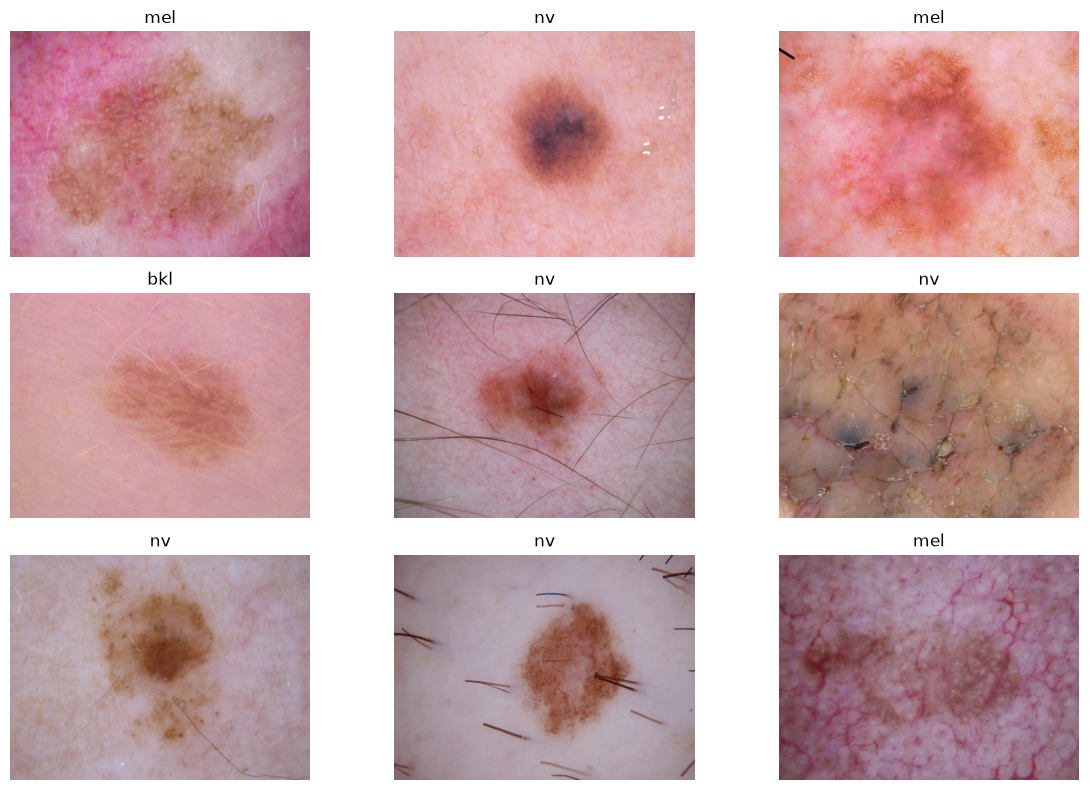

In [18]:
# sample images

from PIL import Image

plt.figure(figsize=(12, 8))
sample = data.sample(9, random_state=42)
for i, (_, row) in enumerate(sample.iterrows()):
    img = Image.open(row["image_path"])

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(row["dx"])
    plt.axis("off")

plt.tight_layout()
plt.show()

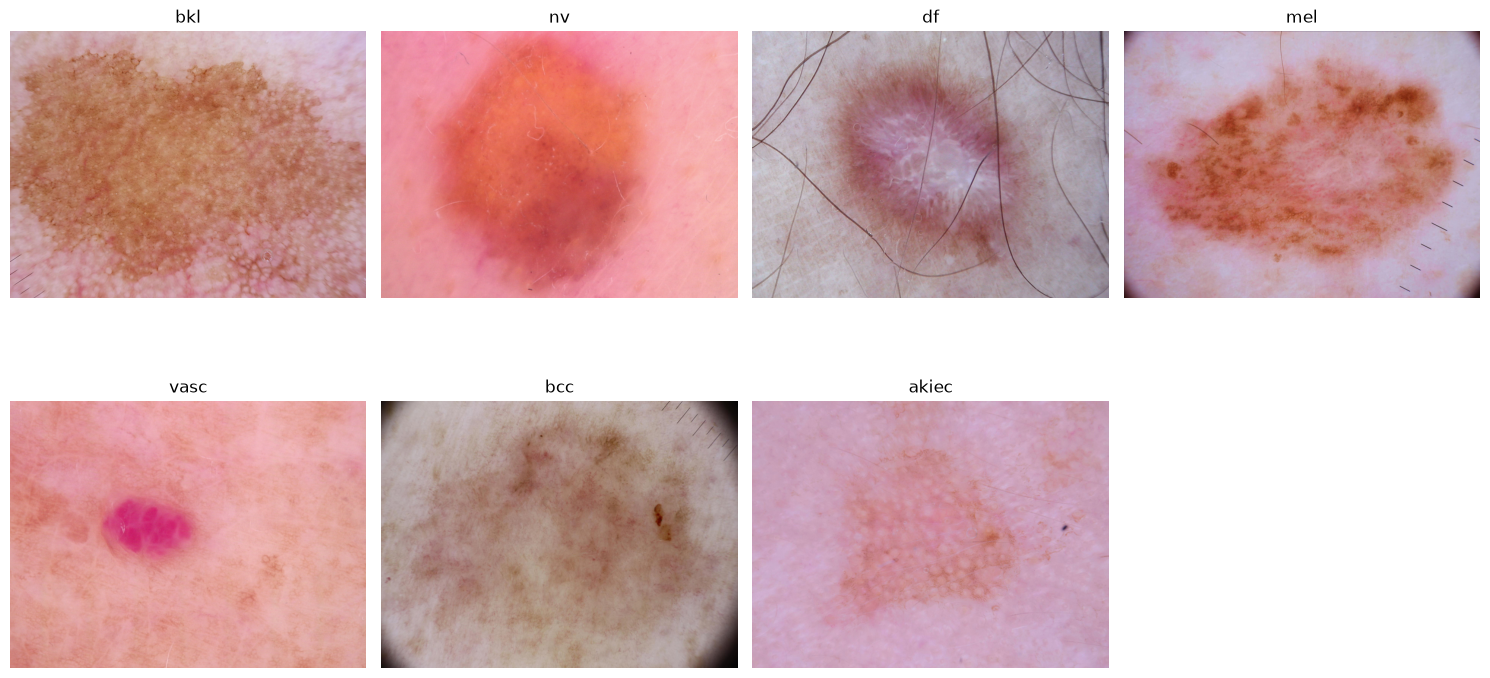

In [19]:
# One Image from Each Disease Class
classes = data["dx"].unique()

plt.figure(figsize=(15,8))

for i, disease in enumerate(classes):

    sample = data[data["dx"] == disease].sample(1, random_state=42)

    img = Image.open(sample.iloc[0]["image_path"])

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(disease)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
# image resolution
widths = []
heights = []
for path in data["image_path"]:

    img = Image.open(path)

    widths.append(img.size[0])
    heights.append(img.size[1])


In [21]:
print("Minimum Width :", min(widths))
print("Maximum Width :", max(widths))

print("Minimum Height :", min(heights))
print("Maximum Height :", max(heights))

Minimum Width : 600
Maximum Width : 600
Minimum Height : 450
Maximum Height : 450


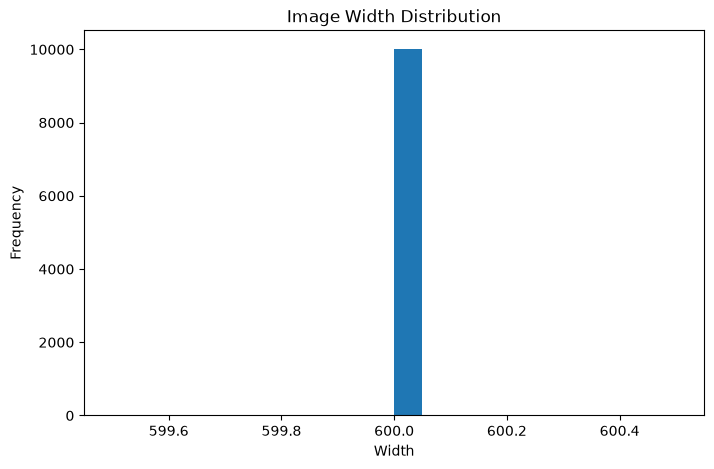

In [22]:
# width distribution
plt.figure(figsize=(8,5))
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")
plt.show()

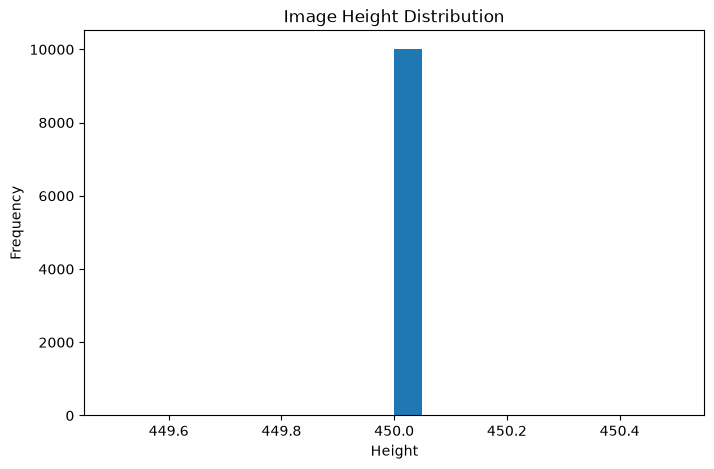

In [23]:
plt.figure(figsize=(8,5))
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()

In [24]:
pip install cv2

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)
ERROR: No matching distribution found for cv2

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\SURYA\tfenv\Scripts\python.exe -m pip install --upgrade pip


In [25]:
import cv2
img = cv2.imread(data.iloc[0]["image_path"])
print(img.shape)

(450, 600, 3)


In [26]:
# tarin validation test-split
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    data,
    test_size=0.30,
    stratify=data["dx"],
    random_state=42
)

In [27]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["dx"],
    random_state=42
)

In [28]:
print("Training Dataset :", train_df.shape)
print("Validation Dataset :", val_df.shape)
print("Testing Dataset :", test_df.shape)

Training Dataset : (7010, 8)
Validation Dataset : (1502, 8)
Testing Dataset : (1503, 8)


In [29]:
print(train_df["dx"].value_counts())

print()

print(val_df["dx"].value_counts())

print()

print(test_df["dx"].value_counts())

dx
nv       4693
mel       779
bkl       769
bcc       360
akiec     229
vasc       99
df         81
Name: count, dtype: int64

dx
nv       1006
mel       167
bkl       165
bcc        77
akiec      49
vasc       21
df         17
Name: count, dtype: int64

dx
nv       1006
mel       167
bkl       165
bcc        77
akiec      49
vasc       22
df         17
Name: count, dtype: int64


In [30]:
train_df.to_csv("dataset/train_metadata.csv", index=False)
val_df.to_csv("dataset/val_metadata.csv", index=False)
test_df.to_csv("dataset/test_metadata.csv", index=False)

# Phase 2 – Data Preprocessing

In [31]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [32]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\SURYA\tfenv\Scripts\python.exe -m pip install --upgrade pip


In [33]:
import sys
print(sys.executable)

C:\Users\SURYA\tfenv\Scripts\python.exe


In [34]:
# resize image
IMAGE_SIZE = (224,224)
image = cv2.imread(data["image_path"].iloc[0])
resized_image = cv2.resize(image, IMAGE_SIZE)
print(resized_image.shape)

(224, 224, 3)


In [35]:
# nomalize pixel values
normalized_image = resized_image / 255.0
print(normalized_image.min())

print(normalized_image.max())


0.1843137254901961
0.996078431372549


### image agumentation

In [36]:
# rotation
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20
)

In [37]:
# horizontal flip
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    horizontal_flip=True
)

In [38]:
# vertical flip
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    vertical_flip=True
)

In [39]:
# zoom
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    zoom_range=0.2
)

In [40]:
# brightness
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    brightness_range=[0.8,1.2]
)

In [41]:
# contrast
contrast = tf.keras.Sequential([
    tf.keras.layers.RandomContrast(0.2)
])

In [42]:
# random crop
crop = tf.keras.Sequential([
    tf.keras.layers.RandomCrop(200,200),
    tf.keras.layers.Resizing(224,224)
])

### purpose - improve robustness to diffrent camera settings

In [43]:
# handli class imbalance
from sklearn.utils.class_weight import compute_class_weight


classes = np.unique(train_df["dx"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["dx"]
)

class_weights = dict(enumerate(weights))
print(class_weights)

{0: np.float64(4.37305053025577), 1: np.float64(2.7817460317460316), 2: np.float64(1.3022478172023035), 3: np.float64(12.36331569664903), 4: np.float64(1.285530900421786), 5: np.float64(0.21338772031292808), 6: np.float64(10.115440115440116)}


In [44]:
#create tensorflow data pipeline


In [45]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(7010, 8)
(1502, 8)
(1503, 8)


In [46]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [47]:
train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=20,

    width_shift_range=0.1,
    height_shift_range=0.1,

    horizontal_flip=True,
    vertical_flip=True,

    zoom_range=0.2,

    brightness_range=[0.8,1.2]
)

In [48]:
# Validation Generator
val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [49]:
# Test Generator
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [50]:
# create train  pipeline
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,

    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

Found 7010 validated image filenames belonging to 7 classes.


In [51]:
# create validatation pipeline
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,

    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)



Found 1502 validated image filenames belonging to 7 classes.


In [52]:
# create test pipeline
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,

    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 1503 validated image filenames belonging to 7 classes.


In [53]:
print(train_generator.class_indices)

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [54]:
# check image batch
images, labels = next(train_generator)

print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32, 7)


# Phase-3 Exploratory Analysis

In [ ]:
# class distribution
counts = train_df["dx"].value_counts()
print(counts)

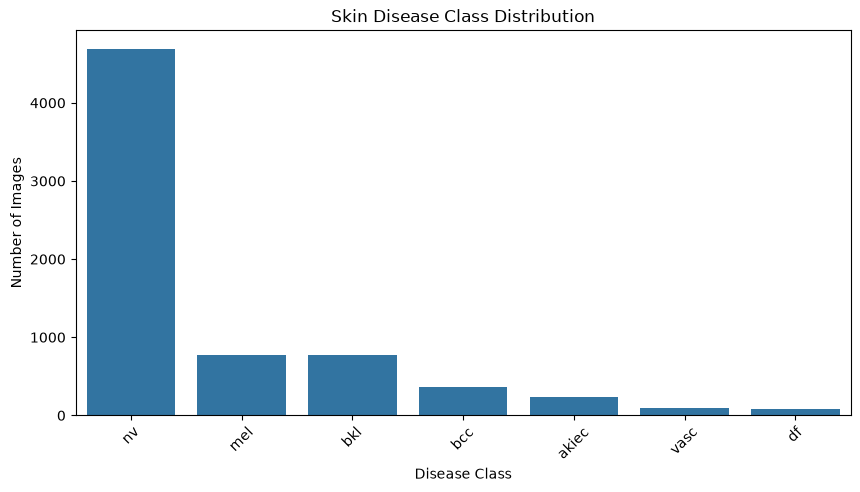

In [134]:
plt.figure(figsize=(10,5))
sns.barplot(x=counts.index, y=counts.values)
plt.title("Skin Disease Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

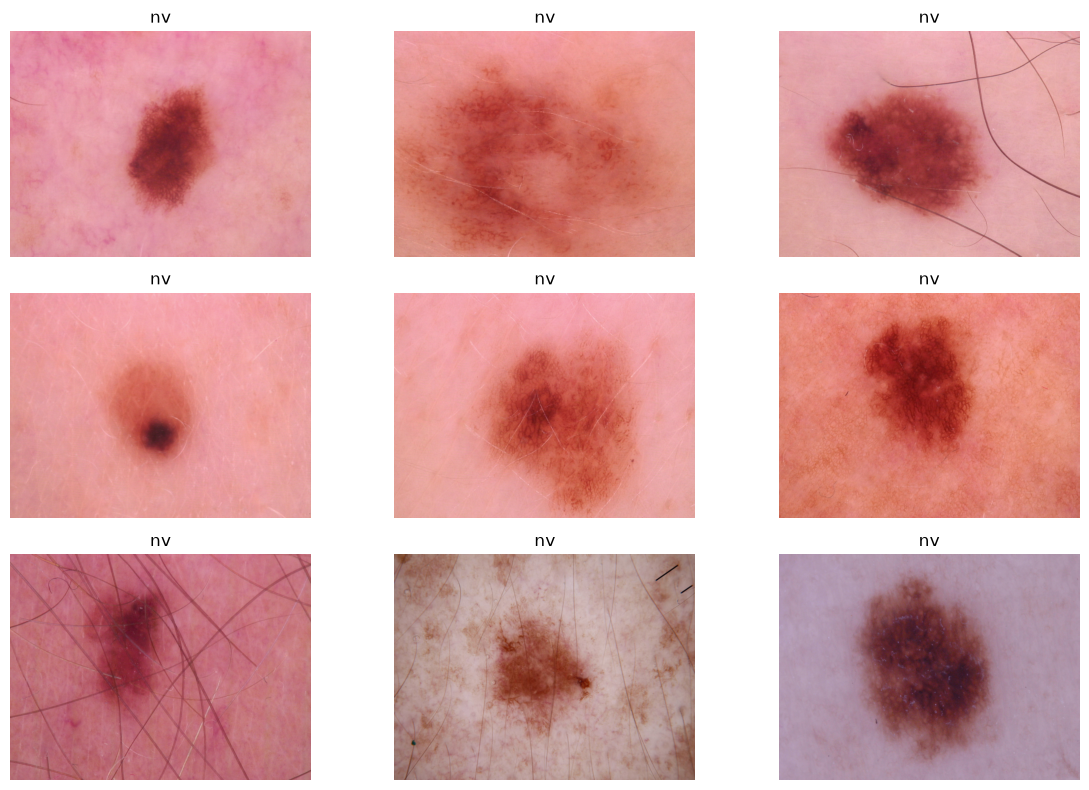

In [135]:
# display sample images
plt.figure(figsize=(12,8))
sample_data = train_df.sample(9)
for i, row in enumerate(sample_data.itertuples()):

    image = cv2.imread(row.image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.subplot(3,3,i+1)
    plt.imshow(image)
    plt.title(row.dx)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [136]:
# image resolution analysis
widths = []
heights = []
for path in train_df["image_path"].sample(500):

    img = cv2.imread(path)
    h,w,_ = img.shape
    heights.append(h)
    widths.append(w)
print("Average height:", np.mean(heights))
print("Average width:", np.mean(widths))

Average height: 450.0
Average width: 600.0


In [137]:
# pixel intensity analysis (understand image brightness)
image = cv2.imread(train_df["image_path"].iloc[0])
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

print("Minimum pixel:",image.min())
print("Maximum pixel:",image.max())
print("Mean pixel:",image.mean())

Minimum pixel: 17
Maximum pixel: 252
Mean pixel: 166.5175024691358


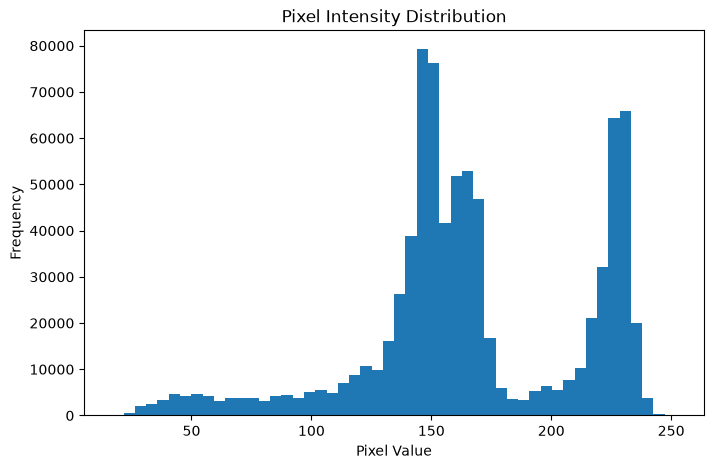

In [138]:
# pixel distribution plot
plt.figure(figsize=(8,5))
plt.hist(image.ravel(),bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

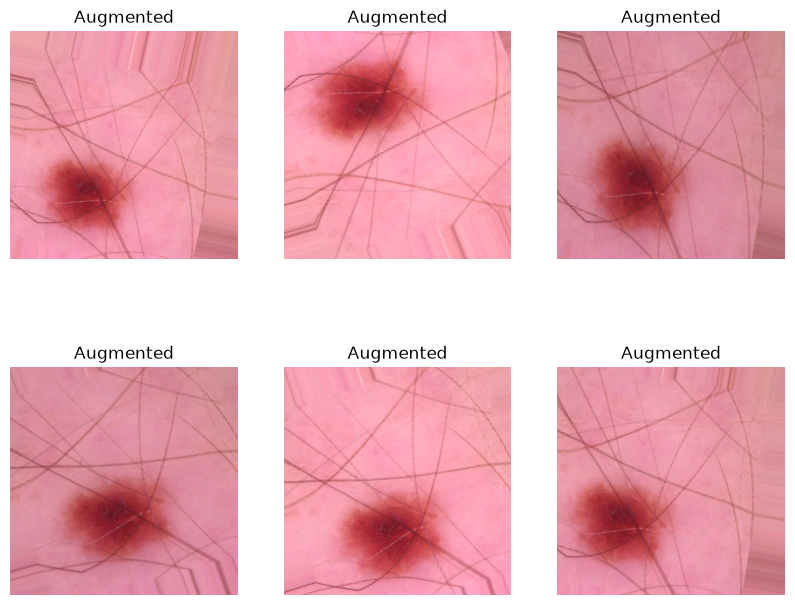

In [139]:
# augumentation comparison
from tensorflow.keras.preprocessing.image import img_to_array, load_img

sample_path = train_df["image_path"].iloc[0]
img = load_img(sample_path,target_size=(224,224))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

augmented_images = train_datagen.flow(img_array, batch_size=1)
plt.figure(figsize=(10,8))
for i in range(6):
    batch = next(augmented_images)
    plt.subplot(2,3,i+1)
    plt.imshow(batch[0])
    plt.axis("off")
    plt.title("Augmented")
plt.show()

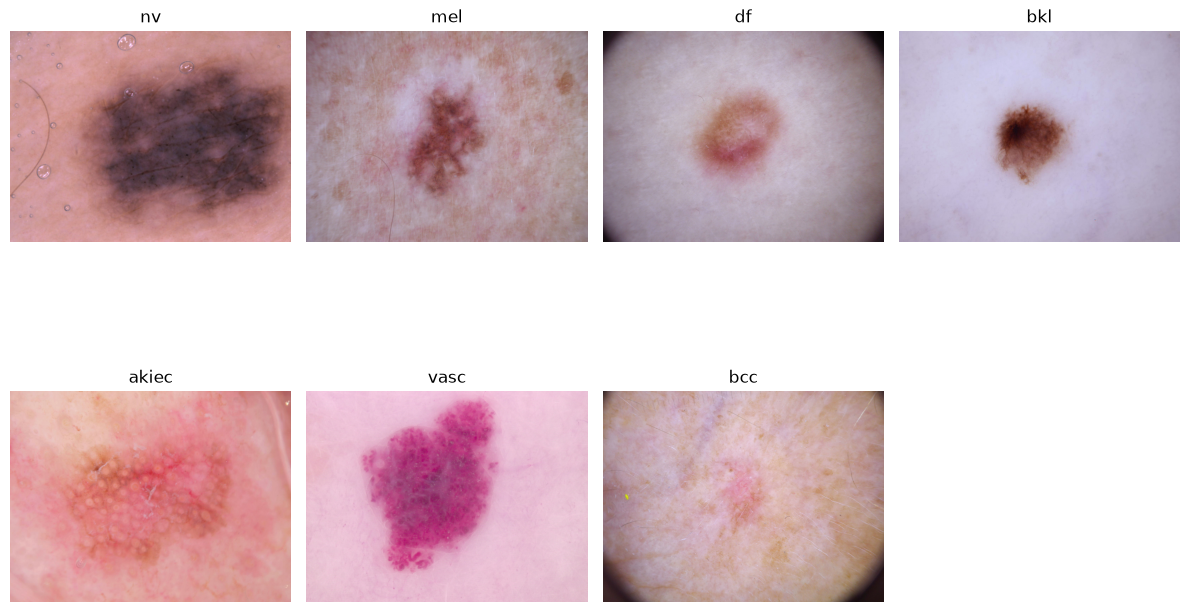

In [140]:
# class wise image charecteristics
plt.figure(figsize=(12,8))

classes = train_df["dx"].unique()

for i, cls in enumerate(classes):
    sample = train_df[train_df["dx"] == cls].sample(1)
    image = cv2.imread(sample["image_path"].values[0])
    image = cv2.cvtColor( image, cv2.COLOR_BGR2RGB )
    plt.subplot(2,4,i+1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis("off")
plt.tight_layout()
plt.show()

# phase-4 Model Development

In [55]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import Adam

In [77]:
# basic cnn model
model_cnn = Sequential()

# First Convolution Block
model_cnn.add(
    Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(224,224,3)))
model_cnn.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Block
model_cnn.add(
    Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model_cnn.add(MaxPooling2D(pool_size=(2,2)))

#  maps to vector
model_cnn.add(Flatten())

# Fully Connected Layer
model_cnn.add(Dense(128, activation='relu'))

# Output Layer
model_cnn.add(Dense(7, activation='softmax'))

C:\Users\SURYA\tfenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [78]:
model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)       ┃ Output Shape ┃ Param # ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ conv2d (Conv2D)    │ (None, 222,  │     896 │
│                    │ 222, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d      │ (None, 111,  │       0 │
│ (MaxPooling2D)     │ 111, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ conv2d_1 (Conv2D)  │ (None, 109,  │  18,496 │
│                    │ 109, 64)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_1    │ (None, 54,   │       0 │
│ (MaxPooling2D)     │ 54, 64)      │         │
├────────────────────┼──────────────┼─────────┤
│ flatten (Flatten)  │ (None,       │       0 │
│                    │ 186624)      │         │
├────────────────────┼──────────────┼─────────┤
│ dense (Dense)      │ (None, 128)  │ 23,888… │
├────────────────────┼──────────────┼─────────┤
│ dense_1 (Dense)    │ (None, 7)    │     903 │
└────────────────────┴──────────────┴─────────┘

 Total params: 23,908,295 (91.20 MB)

 Trainable params: 23,908,295 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [84]:
model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)       ┃ Output Shape ┃ Param # ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ conv2d (Conv2D)    │ (None, 222,  │     896 │
│                    │ 222, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d      │ (None, 111,  │       0 │
│ (MaxPooling2D)     │ 111, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ conv2d_1 (Conv2D)  │ (None, 109,  │  18,496 │
│                    │ 109, 64)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_1    │ (None, 54,   │       0 │
│ (MaxPooling2D)     │ 54, 64)      │         │
├────────────────────┼──────────────┼─────────┤
│ flatten (Flatten)  │ (None,       │       0 │
│                    │ 186624)      │         │
├────────────────────┼──────────────┼─────────┤
│ dense (Dense)      │ (None, 128)  │ 23,888… │
├────────────────────┼──────────────┼─────────┤
│ dense_1 (Dense)    │ (None, 7)    │     903 │
└────────────────────┴──────────────┴─────────┘

 Total params: 71,724,887 (273.61 MB)

 Trainable params: 23,908,295 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 47,816,592 (182.41 MB)

In [81]:
model_cnn.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [82]:
model_cnn.optimizer

In [83]:
# train basic cnn
history_cnn = model_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 448s 2s/step - accuracy: 0.3556 - loss: 1.9520 - val_accuracy: 0.4720 - val_loss: 1.5030
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 592s 2s/step - accuracy: 0.4719 - loss: 1.7602 - val_accuracy: 0.5526 - val_loss: 1.3092
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 707s 3s/step - accuracy: 0.4633 - loss: 1.5918 - val_accuracy: 0.4614 - val_loss: 1.3643
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 783s 3s/step - accuracy: 0.4862 - loss: 1.4632 - val_accuracy: 0.4767 - val_loss: 1.3133
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 701s 3s/step - accuracy: 0.4886 - loss: 1.4379 - val_accuracy: 0.5246 - val_loss: 1.2501


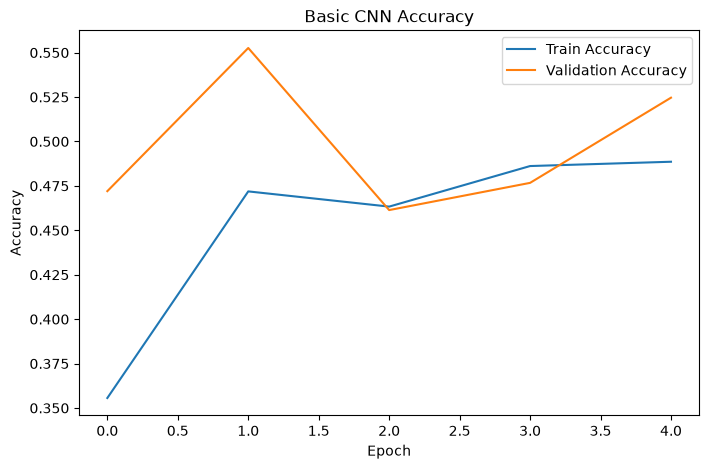

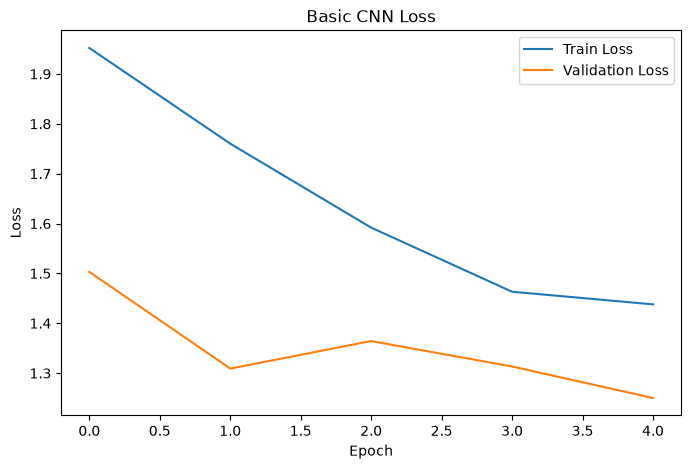

In [85]:
# plotty accourance nd curve
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history_cnn.history["accuracy"], label="Train Accuracy")
plt.plot(history_cnn.history["val_accuracy"], label="Validation Accuracy")
plt.title("Basic CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history_cnn.history["loss"], label="Train Loss")
plt.plot(history_cnn.history["val_loss"], label="Validation Loss")
plt.title("Basic CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [87]:
import os
os.makedirs("models", exist_ok=True)
model_cnn.save("models/basic_cnn.keras")

In [141]:
from tensorflow.keras.models import load_model
model_cnn = load_model("models/basic_cnn.keras")

In [142]:
#
train_loss, train_acc = model_cnn.evaluate(train_generator)
val_loss, val_acc = model_cnn.evaluate(val_generator)
test_loss, test_acc = model_cnn.evaluate(test_generator)

220/220 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.4993 - loss: 1.3031
47/47 ━━━━━━━━━━━━━━━━━━━━ 25s 533ms/step - accuracy: 0.5246 - loss: 1.2501
47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 551ms/step - accuracy: 0.4930 - loss: 1.2747


In [198]:
comparison = []
comparison.append({
    "Model": "Basic CNN",
    "Train Accuracy": 49.93,
    "Validation Accuracy": 52.46,
    "Test Accuracy": 49.30,
    "Train Loss": 1.3031,
    "Validation Loss": 1.2501,
    "Test Loss": 1.2747
})

In [199]:
comparison_datas = pd.DataFrame(comparison)
comparison_datas

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,49.93,52.46,49.3,1.3031,1.2501,1.2747


### DEEP CNN

In [89]:
deep_cnn = Sequential()

# Block 1
deep_cnn.add(Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)))
deep_cnn.add(MaxPooling2D((2,2)))

# Block 2
deep_cnn.add(Conv2D(64, (3,3), activation="relu"))
deep_cnn.add(MaxPooling2D((2,2)))

# Block 3
deep_cnn.add(Conv2D(128, (3,3), activation="relu"))
deep_cnn.add(MaxPooling2D((2,2)))

# Block 4
deep_cnn.add(Conv2D(256, (3,3), activation="relu"))
deep_cnn.add(MaxPooling2D((2,2)))

# Fully Connected Layer
deep_cnn.add(Flatten())
deep_cnn.add(Dense(256, activation="relu"))

# Output Layer (7 diseases)
deep_cnn.add(Dense(7, activation="softmax"))

deep_cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)       ┃ Output Shape ┃ Param # ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ conv2d_2 (Conv2D)  │ (None, 222,  │     896 │
│                    │ 222, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_2    │ (None, 111,  │       0 │
│ (MaxPooling2D)     │ 111, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ conv2d_3 (Conv2D)  │ (None, 109,  │  18,496 │
│                    │ 109, 64)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_3    │ (None, 54,   │       0 │
│ (MaxPooling2D)     │ 54, 64)      │         │
├────────────────────┼──────────────┼─────────┤
│ conv2d_4 (Conv2D)  │ (None, 52,   │  73,856 │
│                    │ 52, 128)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_4    │ (None, 26,   │       0 │
│ (MaxPooling2D)     │ 26, 128)     │         │
├────────────────────┼──────────────┼─────────┤
│ conv2d_5 (Conv2D)  │ (None, 24,   │ 295,168 │
│                    │ 24, 256)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_5    │ (None, 12,   │       0 │
│ (MaxPooling2D)     │ 12, 256)     │         │
├────────────────────┼──────────────┼─────────┤
│ flatten_1          │ (None,       │       0 │
│ (Flatten)          │ 36864)       │         │
├────────────────────┼──────────────┼─────────┤
│ dense_2 (Dense)    │ (None, 256)  │ 9,437,… │
├────────────────────┼──────────────┼─────────┤
│ dense_3 (Dense)    │ (None, 7)    │   1,799 │
└────────────────────┴──────────────┴─────────┘

 Total params: 9,827,655 (37.49 MB)

 Trainable params: 9,827,655 (37.49 MB)

 Non-trainable params: 0 (0.00 B)

In [90]:
# compile the model
deep_cnn.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [91]:
history_deep = deep_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 943s 4s/step - accuracy: 0.4124 - loss: 1.8635 - val_accuracy: 0.4667 - val_loss: 1.4129
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 879s 4s/step - accuracy: 0.4285 - loss: 1.6785 - val_accuracy: 0.4607 - val_loss: 1.3777
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 920s 4s/step - accuracy: 0.4591 - loss: 1.4690 - val_accuracy: 0.5166 - val_loss: 1.1733
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 768s 3s/step - accuracy: 0.4559 - loss: 1.4017 - val_accuracy: 0.5752 - val_loss: 1.0789
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 543s 2s/step - accuracy: 0.4797 - loss: 1.3525 - val_accuracy: 0.4874 - val_loss: 1.2767


In [92]:
test_loss, test_accuracy = deep_cnn.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 32s 677ms/step - accuracy: 0.4664 - loss: 1.3052
Test Loss: 1.3052268028259277
Test Accuracy: 0.46640053391456604


In [93]:
deep_cnn.save("models/deep_cnn.keras")

In [144]:
from tensorflow.keras.models import load_model
deep_cnn = load_model("models/deep_cnn.keras")

In [145]:
#
train_loss, train_acc = deep_cnn.evaluate(train_generator)
val_loss, val_acc = deep_cnn.evaluate(val_generator)
test_loss, test_accuracy = deep_cnn.evaluate(test_generator)


220/220 ━━━━━━━━━━━━━━━━━━━━ 290s 1s/step - accuracy: 0.4481 - loss: 1.3692
47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 602ms/step - accuracy: 0.4874 - loss: 1.2767
47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 607ms/step - accuracy: 0.4664 - loss: 1.3052


In [200]:
comparison.append({
    "Model": "Deep CNN",
    "Train Accuracy": 47.97,
    "Validation Accuracy": 48.74,
    "Test Accuracy": 46.64,
    "Train Loss": 1.3525,
    "Validation Loss": 1.2767,
    "Test Loss": 1.3052
})

In [201]:
comparison_datas = pd.DataFrame(comparison)
comparison_datas

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,49.93,52.46,49.30,1.3031,1.2501,1.2747
1,Deep CNN,47.97,48.74,46.64,1.3525,1.2767,1.3052


### Batch normalization

In [99]:
from tensorflow.keras.layers import BatchNormalization

In [101]:
batch_normalization = Sequential(name="CNN_BatchNormalization")

# Block 1
batch_normalization.add(Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)))
batch_normalization.add(BatchNormalization())
batch_normalization.add(MaxPooling2D((2,2)))

# Block 2
batch_normalization.add(Conv2D(64, (3,3), activation="relu"))
batch_normalization.add(BatchNormalization())
batch_normalization.add(MaxPooling2D((2,2)))

# Block 3
batch_normalization.add(Conv2D(128, (3,3), activation="relu"))
batch_normalization.add(BatchNormalization())
batch_normalization.add(MaxPooling2D((2,2)))

# Block 4
batch_normalization.add(Conv2D(256, (3,3), activation="relu"))
batch_normalization.add(BatchNormalization())
batch_normalization.add(MaxPooling2D((2,2)))

# Fully Connected Layer
batch_normalization.add(Flatten())
batch_normalization.add(Dense(256, activation="relu"))

# Output Layer
batch_normalization.add(Dense(7, activation="softmax"))

batch_normalization.summary()

Model: "CNN_BatchNormalization"

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)       ┃ Output Shape ┃ Param # ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ conv2d_10 (Conv2D) │ (None, 222,  │     896 │
│                    │ 222, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ batch_normalizati… │ (None, 222,  │     128 │
│ (BatchNormalizati… │ 222, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_10   │ (None, 111,  │       0 │
│ (MaxPooling2D)     │ 111, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ conv2d_11 (Conv2D) │ (None, 109,  │  18,496 │
│                    │ 109, 64)     │         │
├────────────────────┼──────────────┼─────────┤
│ batch_normalizati… │ (None, 109,  │     256 │
│ (BatchNormalizati… │ 109, 64)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_11   │ (None, 54,   │       0 │
│ (MaxPooling2D)     │ 54, 64)      │         │
├────────────────────┼──────────────┼─────────┤
│ conv2d_12 (Conv2D) │ (None, 52,   │  73,856 │
│                    │ 52, 128)     │         │
├────────────────────┼──────────────┼─────────┤
│ batch_normalizati… │ (None, 52,   │     512 │
│ (BatchNormalizati… │ 52, 128)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_12   │ (None, 26,   │       0 │
│ (MaxPooling2D)     │ 26, 128)     │         │
├────────────────────┼──────────────┼─────────┤
│ conv2d_13 (Conv2D) │ (None, 24,   │ 295,168 │
│                    │ 24, 256)     │         │
├────────────────────┼──────────────┼─────────┤
│ batch_normalizati… │ (None, 24,   │   1,024 │
│ (BatchNormalizati… │ 24, 256)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_13   │ (None, 12,   │       0 │
│ (MaxPooling2D)     │ 12, 256)     │         │
├────────────────────┼──────────────┼─────────┤
│ flatten_3          │ (None,       │       0 │
│ (Flatten)          │ 36864)       │         │
├────────────────────┼──────────────┼─────────┤
│ dense_6 (Dense)    │ (None, 256)  │ 9,437,… │
├────────────────────┼──────────────┼─────────┤
│ dense_7 (Dense)    │ (None, 7)    │   1,799 │
└────────────────────┴──────────────┴─────────┘

 Total params: 9,829,575 (37.50 MB)

 Trainable params: 9,828,615 (37.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [102]:
batch_normalization.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [103]:
history_batch_normalization = batch_normalization.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 765s 3s/step - accuracy: 0.4180 - loss: 2.1976 - val_accuracy: 0.0140 - val_loss: 7.8258
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 765s 3s/step - accuracy: 0.4951 - loss: 1.4516 - val_accuracy: 0.6039 - val_loss: 1.5762
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 760s 3s/step - accuracy: 0.5136 - loss: 1.3018 - val_accuracy: 0.5679 - val_loss: 1.2165
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 841s 4s/step - accuracy: 0.5161 - loss: 1.3110 - val_accuracy: 0.4854 - val_loss: 1.4365
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 1329s 6s/step - accuracy: 0.5355 - loss: 1.2778 - val_accuracy: 0.4820 - val_loss: 1.4709


In [106]:
# Validation Accuracy
test_loss, test_accuracy = batch_normalization.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.4697 - loss: 1.5244
Test Loss: 1.5244275331497192
Test Accuracy: 0.46972721815109253


In [107]:
batch_normalization.save("models/batch_normalization.keras")

print("CNN + Batch Normalization model saved successfully!")

CNN + Batch Normalization model saved successfully!


In [147]:
from tensorflow.keras.models import load_model
batch_normalization = load_model("models/batch_normalization.keras")

In [148]:
# Accuracy
train_loss, train_acc = batch_normalization.evaluate(train_generator)
val_loss, val_acc = batch_normalization.evaluate(val_generator)
test_loss, test_accuracy = batch_normalization.evaluate(test_generator)


220/220 ━━━━━━━━━━━━━━━━━━━━ 298s 1s/step - accuracy: 0.4645 - loss: 1.5012
47/47 ━━━━━━━━━━━━━━━━━━━━ 32s 675ms/step - accuracy: 0.4820 - loss: 1.4709
47/47 ━━━━━━━━━━━━━━━━━━━━ 32s 678ms/step - accuracy: 0.4697 - loss: 1.5244


In [202]:
comparison.append({
    "Model": "CNN + Batch Normalization",
    "Train Accuracy": 47.55,
    "Validation Accuracy": 48.20,
    "Test Accuracy": 46.97,
    "Train Loss": 1.2778,
    "Validation Loss": 1.4709,
    "Test Loss": 1.5244
})

In [203]:
comparison_datas = pd.DataFrame(comparison)
comparison_datas

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,49.93,52.46,49.30,1.3031,1.2501,1.2747
1,Deep CNN,47.97,48.74,46.64,1.3525,1.2767,1.3052
2,CNN + Batch Normalization,47.55,48.20,46.97,1.2778,1.4709,1.5244


### Cnn dropout

In [56]:
# CNN DROOUT
from tensorflow.keras.layers import Dropout

In [111]:
cnn_dropout = Sequential(name="CNN_Dropout")

# Block 1
cnn_dropout.add(Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)))
cnn_dropout.add(MaxPooling2D((2,2)))
cnn_dropout.add(Dropout(0.25))

# Block 2
cnn_dropout.add(Conv2D(64, (3,3), activation="relu"))
cnn_dropout.add(MaxPooling2D((2,2)))
cnn_dropout.add(Dropout(0.25))

# Block 3
cnn_dropout.add(Conv2D(128, (3,3), activation="relu"))
cnn_dropout.add(MaxPooling2D((2,2)))
cnn_dropout.add(Dropout(0.25))

# Block 4
cnn_dropout.add(Conv2D(256, (3,3), activation="relu"))
cnn_dropout.add(MaxPooling2D((2,2)))
cnn_dropout.add(Dropout(0.25))

# Fully Connected Layer
cnn_dropout.add(Flatten())
cnn_dropout.add(Dense(256, activation="relu"))
cnn_dropout.add(Dropout(0.5))

# Output Layer
cnn_dropout.add(Dense(7, activation="softmax"))

cnn_dropout.summary()

Model: "CNN_Dropout"

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)       ┃ Output Shape ┃ Param # ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ conv2d_15 (Conv2D) │ (None, 222,  │     896 │
│                    │ 222, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_15   │ (None, 111,  │       0 │
│ (MaxPooling2D)     │ 111, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ dropout (Dropout)  │ (None, 111,  │       0 │
│                    │ 111, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ conv2d_16 (Conv2D) │ (None, 109,  │  18,496 │
│                    │ 109, 64)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_16   │ (None, 54,   │       0 │
│ (MaxPooling2D)     │ 54, 64)      │         │
├────────────────────┼──────────────┼─────────┤
│ dropout_1          │ (None, 54,   │       0 │
│ (Dropout)          │ 54, 64)      │         │
├────────────────────┼──────────────┼─────────┤
│ conv2d_17 (Conv2D) │ (None, 52,   │  73,856 │
│                    │ 52, 128)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_17   │ (None, 26,   │       0 │
│ (MaxPooling2D)     │ 26, 128)     │         │
├────────────────────┼──────────────┼─────────┤
│ dropout_2          │ (None, 26,   │       0 │
│ (Dropout)          │ 26, 128)     │         │
├────────────────────┼──────────────┼─────────┤
│ conv2d_18 (Conv2D) │ (None, 24,   │ 295,168 │
│                    │ 24, 256)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_18   │ (None, 12,   │       0 │
│ (MaxPooling2D)     │ 12, 256)     │         │
├────────────────────┼──────────────┼─────────┤
│ dropout_3          │ (None, 12,   │       0 │
│ (Dropout)          │ 12, 256)     │         │
├────────────────────┼──────────────┼─────────┤
│ flatten_4          │ (None,       │       0 │
│ (Flatten)          │ 36864)       │         │
├────────────────────┼──────────────┼─────────┤
│ dense_8 (Dense)    │ (None, 256)  │ 9,437,… │
├────────────────────┼──────────────┼─────────┤
│ dropout_4          │ (None, 256)  │       0 │
│ (Dropout)          │              │         │
├────────────────────┼──────────────┼─────────┤
│ dense_9 (Dense)    │ (None, 7)    │   1,799 │
└────────────────────┴──────────────┴─────────┘

 Total params: 9,827,655 (37.49 MB)

 Trainable params: 9,827,655 (37.49 MB)

 Non-trainable params: 0 (0.00 B)

In [112]:
cnn_dropout.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [113]:
history_dropout = cnn_dropout.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 839s 4s/step - accuracy: 0.3582 - loss: 1.9528 - val_accuracy: 0.4634 - val_loss: 1.6980
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 487s 2s/step - accuracy: 0.3999 - loss: 1.8411 - val_accuracy: 0.4854 - val_loss: 1.4673
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 482s 2s/step - accuracy: 0.3987 - loss: 1.8197 - val_accuracy: 0.4607 - val_loss: 1.5753
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 483s 2s/step - accuracy: 0.4272 - loss: 1.7709 - val_accuracy: 0.5386 - val_loss: 1.3380
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 478s 2s/step - accuracy: 0.4320 - loss: 1.7103 - val_accuracy: 0.5593 - val_loss: 1.3193


In [252]:
test_loss, test_accuracy = cnn_dropout.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 31s 648ms/step - accuracy: 0.5669 - loss: 1.3342
Test Loss: 1.3342143297195435
Test Accuracy: 0.5668662786483765


In [253]:
cnn_dropout.save("models/CNN_Dropout.keras")

print("dropout model saved successfully!")

dropout model saved successfully!


In [149]:
from tensorflow.keras.models import load_model
cnn_dropout = load_model("models/CNN_Dropout.keras")

In [150]:
# Accuracy
train_loss, train_acc = cnn_dropout.evaluate(train_generator)
val_loss, val_acc = cnn_dropout.evaluate(val_generator)
test_loss, test_accuracy = cnn_dropout.evaluate(test_generator)


220/220 ━━━━━━━━━━━━━━━━━━━━ 285s 1s/step - accuracy: 0.5324 - loss: 1.3640
47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 607ms/step - accuracy: 0.5593 - loss: 1.3193
47/47 ━━━━━━━━━━━━━━━━━━━━ 30s 638ms/step - accuracy: 0.5669 - loss: 1.3342


In [204]:
comparison.append({
    "Model": "CNN + Dropout",
    "Train Accuracy": 53.24,
    "Validation Accuracy": 55.93,
    "Test Accuracy": 56.69,
    "Train Loss": 1.3640,
    "Validation Loss": 1.3193,
    "Test Loss": 1.3342
})

In [205]:
comparison_datas = pd.DataFrame(comparison)
comparison_datas

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,49.93,52.46,49.30,1.3031,1.2501,1.2747
1,Deep CNN,47.97,48.74,46.64,1.3525,1.2767,1.3052
2,CNN + Batch Normalization,47.55,48.20,46.97,1.2778,1.4709,1.5244
3,CNN + Dropout,53.24,55.93,56.69,1.3640,1.3193,1.3342


In [232]:
train_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path
4357,HAM_0000946,ISIC_0031775,nv,follow_up,60.0,male,trunk,dataset/HAM10000_images_part_2\ISIC_0031775.jpg
1751,HAM_0006097,ISIC_0027306,mel,histo,60.0,male,chest,dataset/HAM10000_images_part_1\ISIC_0027306.jpg
9527,HAM_0004348,ISIC_0033895,nv,consensus,40.0,female,unknown,dataset/HAM10000_images_part_2\ISIC_0033895.jpg
8311,HAM_0006608,ISIC_0025491,nv,histo,60.0,male,back,dataset/HAM10000_images_part_1\ISIC_0025491.jpg
1214,HAM_0005678,ISIC_0031023,mel,histo,60.0,male,chest,dataset/HAM10000_images_part_2\ISIC_0031023.jpg


### Efficientnet

In [62]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

In [176]:
# create new data generator
train_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2]
)

val_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [177]:
train_generator_eff = train_datagen_eff.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

val_generator_eff = val_datagen_eff.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test_generator_eff = test_datagen_eff.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [178]:
train_generator_eff = train_datagen_eff.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

val_generator_eff = val_datagen_eff.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test_generator_eff = test_datagen_eff.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [63]:
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

output = Dense(7, activation="softmax")(x)

efficientnet_model = Model(
    inputs=base_model.input,
    outputs=output,
    name="EfficientNetB0"
)

In [264]:
efficientnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [265]:
history_efficientnet = efficientnet_model.fit(
    train_generator_eff,
    validation_data=val_generator_eff,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 710s 3s/step - accuracy: 0.2766 - loss: 1.8800 - val_accuracy: 0.5133 - val_loss: 1.5602
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 661s 3s/step - accuracy: 0.4295 - loss: 1.5994 - val_accuracy: 0.5386 - val_loss: 1.3830
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 683s 3s/step - accuracy: 0.4649 - loss: 1.4730 - val_accuracy: 0.5613 - val_loss: 1.2747
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 669s 3s/step - accuracy: 0.5066 - loss: 1.3684 - val_accuracy: 0.5652 - val_loss: 1.2441
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 666s 3s/step - accuracy: 0.5168 - loss: 1.3004 - val_accuracy: 0.5626 - val_loss: 1.2470


In [266]:
test_loss, test_accuracy = efficientnet_model.evaluate(test_generator_eff)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.5449 - loss: 1.2937
Test Loss: 1.2937291860580444
Test Accuracy: 0.544910192489624


In [179]:
efficientnet_model.save("models/efficientnetb0.keras")
print("EfficientNetB0 model saved successfully!")

EfficientNetB0 model saved successfully!


In [180]:
from tensorflow.keras.models import load_model
efficientnet_model = load_model("models/efficientnetb0.keras")

In [181]:
# Accuracy
train_loss, train_acc = efficientnet_model.evaluate(train_generator_eff)
val_loss, val_acc = efficientnet_model.evaluate(val_generator_eff)
test_loss, test_accuracy = efficientnet_model.evaluate(test_generator_eff)


220/220 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.5593 - loss: 1.2708
47/47 ━━━━━━━━━━━━━━━━━━━━ 37s 781ms/step - accuracy: 0.5626 - loss: 1.2470
47/47 ━━━━━━━━━━━━━━━━━━━━ 38s 794ms/step - accuracy: 0.5449 - loss: 1.2937


In [206]:
comparison.append({
    "Model": "EfficientNetB0",
    "Train Accuracy": 55.93,
    "Validation Accuracy": 56.26,
    "Test Accuracy": 54.49,
    "Train Loss": 1.2708,
    "Validation Loss": 1.2470,
    "Test Loss": 1.2937
})

In [207]:
comparison_datas = pd.DataFrame(comparison)
comparison_datas

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,49.93,52.46,49.30,1.3031,1.2501,1.2747
1,Deep CNN,47.97,48.74,46.64,1.3525,1.2767,1.3052
2,CNN + Batch Normalization,47.55,48.20,46.97,1.2778,1.4709,1.5244
3,CNN + Dropout,53.24,55.93,56.69,1.3640,1.3193,1.3342
4,EfficientNetB0,55.93,56.26,54.49,1.2708,1.2470,1.2937


### ResNet50

In [169]:
from tensorflow.keras.applications.resnet50 import preprocess_input

In [170]:
# image generators
train_datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,    
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8,1.2]
)

val_datagen_resnet = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen_resnet = ImageDataGenerator(preprocessing_function=preprocess_input)

In [171]:
# data generators
train_generator_resnet = train_datagen_resnet.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

val_generator_resnet = val_datagen_resnet.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test_generator_resnet = test_datagen_resnet.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [276]:
#create model
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(7, activation="softmax")(x)

resnet_model = Model(
    inputs=base_model.input,
    outputs=output,
    name="ResNet50"
)

resnet_model.summary()

Model: "ResNet50"

┏━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━┓
┃ Layer       ┃ Output    ┃ Par… ┃ Connected  ┃
┃ (type)      ┃ Shape     ┃    # ┃ to         ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━┩
│ input_laye… │ (None,    │    0 │ -          │
│ (InputLaye… │ 224, 224, │      │            │
│             │ 3)        │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv1_pad   │ (None,    │    0 │ input_lay… │
│ (ZeroPaddi… │ 230, 230, │      │            │
│             │ 3)        │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv1_conv  │ (None,    │ 9,4… │ conv1_pad… │
│ (Conv2D)    │ 112, 112, │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv1_bn    │ (None,    │  256 │ conv1_con… │
│ (BatchNorm… │ 112, 112, │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv1_relu  │ (None,    │    0 │ conv1_bn[… │
│ (Activatio… │ 112, 112, │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ pool1_pad   │ (None,    │    0 │ conv1_rel… │
│ (ZeroPaddi… │ 114, 114, │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ pool1_pool  │ (None,    │    0 │ pool1_pad… │
│ (MaxPoolin… │ 56, 56,   │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │ 4,1… │ pool1_poo… │
│ (Conv2D)    │ 56, 56,   │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │  256 │ conv2_blo… │
│ (BatchNorm… │ 56, 56,   │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │    0 │ conv2_blo… │
│ (Activatio… │ 56, 56,   │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │ 36,… │ conv2_blo… │
│ (Conv2D)    │ 56, 56,   │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │  256 │ conv2_blo… │
│ (BatchNorm… │ 56, 56,   │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │    0 │ conv2_blo… │
│ (Activatio… │ 56, 56,   │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │ 16,… │ pool1_poo… │
│ (Conv2D)    │ 56, 56,   │      │            │
│             │ 256)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │ 16,… │ conv2_blo… │
│ (Conv2D)    │ 56, 56,   │      │            │
│             │ 256)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │ 1,0… │ conv2_blo… │
│ (BatchNorm… │ 56, 56,   │      │            │
│             │ 256)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │ 1,0… │ conv2_blo… │
│ (BatchNorm… │ 56, 56,   │      │            │
│             │ 256)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │    0 │ conv2_blo… │
│ (Add)       │ 56, 56,   │      │ conv2_blo… │
│             │ 256)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │    0 │ conv2_blo… │
│ (Activatio… │ 56, 56,   │      │            │
│             │ 256)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │ 16,… │ conv2_blo… │
│ (Conv2D)    │ 56, 56,   │      │            │
│             │ 64)       │      │            │
├─────────────┼─

 Total params: 24,114,055 (91.99 MB)

 Trainable params: 526,343 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [277]:
# compile the model
resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [278]:
# train the model
history_resnet = resnet_model.fit(
    train_generator_resnet,
    validation_data=val_generator_resnet,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 1602s 7s/step - accuracy: 0.3267 - loss: 1.9796 - val_accuracy: 0.5919 - val_loss: 1.1674
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 1588s 7s/step - accuracy: 0.4882 - loss: 1.4523 - val_accuracy: 0.5666 - val_loss: 1.1809
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 1567s 7s/step - accuracy: 0.5064 - loss: 1.3570 - val_accuracy: 0.5885 - val_loss: 1.0995
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 1740s 8s/step - accuracy: 0.5429 - loss: 1.2246 - val_accuracy: 0.6345 - val_loss: 0.9804
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 1708s 8s/step - accuracy: 0.5678 - loss: 1.1781 - val_accuracy: 0.5925 - val_loss: 1.0551


In [279]:
test_loss, test_accuracy = resnet_model.evaluate(test_generator_resnet)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 267s 6s/step - accuracy: 0.5755 - loss: 1.1118
Test Loss: 1.1117609739303589
Test Accuracy: 0.575515627861023


In [345]:
resnet_model.save("models/resnet_model.keras")
print("resnet model saved successfully!")

resnet model saved successfully!


In [172]:
from tensorflow.keras.models import load_model
resnet_model = load_model("models/resnet_model.keras")

In [174]:
# Accuracy
train_loss, train_acc = resnet_model.evaluate(train_generator_resnet)
val_loss, val_acc = resnet_model.evaluate(val_generator_resnet)
test_loss, test_accuracy = resnet_model.evaluate(test_generator_resnet)


220/220 ━━━━━━━━━━━━━━━━━━━━ 445s 2s/step - accuracy: 0.5943 - loss: 1.0916
47/47 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.5925 - loss: 1.0551
47/47 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.5755 - loss: 1.1118


In [208]:
comparison.append({
    "Model": "ResNet50",
    "Train Accuracy": 59.43,
    "Validation Accuracy": 59.25,
    "Test Accuracy": 57.55,
    "Train Loss": 1.0916,
    "Validation Loss": 1.0551,
    "Test Loss": 1.1118
})

In [209]:
comparison_datas = pd.DataFrame(comparison)
comparison_datas

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,49.93,52.46,49.30,1.3031,1.2501,1.2747
1,Deep CNN,47.97,48.74,46.64,1.3525,1.2767,1.3052
2,CNN + Batch Normalization,47.55,48.20,46.97,1.2778,1.4709,1.5244
3,CNN + Dropout,53.24,55.93,56.69,1.3640,1.3193,1.3342
4,EfficientNetB0,55.93,56.26,54.49,1.2708,1.2470,1.2937
5,ResNet50,59.43,59.25,57.55,1.0916,1.0551,1.1118


### DenseNet121

In [156]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

In [157]:
# image generators
train_datagen_dense = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8,1.2]
)

val_datagen_dense = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen_dense = ImageDataGenerator(preprocessing_function=preprocess_input)

In [158]:
# data generators
train_generator_dense = train_datagen_dense.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

val_generator_dense = val_datagen_dense.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test_generator_dense = test_datagen_dense.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [289]:
# model
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(7, activation="softmax")(x)

densenet_model = Model(
    inputs=base_model.input,
    outputs=output,
    name="DenseNet121"
)

densenet_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "DenseNet121"

┏━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━┓
┃ Layer       ┃ Output    ┃ Par… ┃ Connected  ┃
┃ (type)      ┃ Shape     ┃    # ┃ to         ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━┩
│ input_laye… │ (None,    │    0 │ -          │
│ (InputLaye… │ 224, 224, │      │            │
│             │ 3)        │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ zero_paddi… │ (None,    │    0 │ input_lay… │
│ (ZeroPaddi… │ 230, 230, │      │            │
│             │ 3)        │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv1_conv  │ (None,    │ 9,4… │ zero_padd… │
│ (Conv2D)    │ 112, 112, │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv1_bn    │ (None,    │  256 │ conv1_con… │
│ (BatchNorm… │ 112, 112, │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv1_relu  │ (None,    │    0 │ conv1_bn[… │
│ (Activatio… │ 112, 112, │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ zero_paddi… │ (None,    │    0 │ conv1_rel… │
│ (ZeroPaddi… │ 114, 114, │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ pool1       │ (None,    │    0 │ zero_padd… │
│ (MaxPoolin… │ 56, 56,   │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │  256 │ pool1[0][… │
│ (BatchNorm… │ 56, 56,   │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │    0 │ conv2_blo… │
│ (Activatio… │ 56, 56,   │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │ 8,1… │ conv2_blo… │
│ (Conv2D)    │ 56, 56,   │      │            │
│             │ 128)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │  512 │ conv2_blo… │
│ (BatchNorm… │ 56, 56,   │      │            │
│             │ 128)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │    0 │ conv2_blo… │
│ (Activatio… │ 56, 56,   │      │            │
│             │ 128)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │ 36,… │ conv2_blo… │
│ (Conv2D)    │ 56, 56,   │      │            │
│             │ 32)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │    0 │ pool1[0][… │
│ (Concatena… │ 56, 56,   │      │ conv2_blo… │
│             │ 96)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │  384 │ conv2_blo… │
│ (BatchNorm… │ 56, 56,   │      │            │
│             │ 96)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │    0 │ conv2_blo… │
│ (Activatio… │ 56, 56,   │      │            │
│             │ 96)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │ 12,… │ conv2_blo… │
│ (Conv2D)    │ 56, 56,   │      │            │
│             │ 128)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │  512 │ conv2_blo… │
│ (BatchNorm… │ 56, 56,   │      │            │
│             │ 128)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │    0 │ conv2_blo… │
│ (Activatio… │ 56, 56,   │      │            │
│             │ 128)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │ 36,… │ conv2_blo… │
│ (Conv2D)    │ 56, 56,   │      │            │
│             │ 32)       │      │            │
├─────────────┼─

 Total params: 7,301,703 (27.85 MB)

 Trainable params: 264,199 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [290]:
# compile
densenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [293]:
history_densenet = densenet_model.fit(
    train_generator_dense,
    validation_data=val_generator_dense,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 929s 4s/step - accuracy: 0.3442 - loss: 1.7295 - val_accuracy: 0.5686 - val_loss: 1.3666
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 1006s 4s/step - accuracy: 0.4039 - loss: 1.5888 - val_accuracy: 0.5732 - val_loss: 1.3404
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 893s 4s/step - accuracy: 0.4676 - loss: 1.4936 - val_accuracy: 0.6099 - val_loss: 1.2066
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 953s 4s/step - accuracy: 0.4770 - loss: 1.4220 - val_accuracy: 0.5885 - val_loss: 1.1960
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 1332s 6s/step - accuracy: 0.4873 - loss: 1.3829 - val_accuracy: 0.5872 - val_loss: 1.2098


In [294]:
test_loss, test_accuracy = densenet_model.evaluate(test_generator_dense)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 183s 4s/step - accuracy: 0.5655 - loss: 1.2557
Test Loss: 1.2557193040847778
Test Accuracy: 0.5655356049537659


In [295]:
densenet_model.save("models/densenet121.keras")
print("DenseNet121 model saved successfully!")

DenseNet121 model saved successfully!


In [159]:
from tensorflow.keras.models import load_model
densenet_model = load_model("models/densenet121.keras")

In [160]:
# Accuracy
train_loss, train_acc = densenet_model.evaluate(train_generator_dense)
val_loss, val_acc = densenet_model.evaluate(val_generator_dense)
test_loss, test_accuracy = densenet_model.evaluate(test_generator_dense)


220/220 ━━━━━━━━━━━━━━━━━━━━ 473s 2s/step - accuracy: 0.5341 - loss: 1.3109
47/47 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.5872 - loss: 1.2098
47/47 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.5655 - loss: 1.2557


In [210]:
comparison.append({
    "Model": "DenseNet121",
    "Train Accuracy": 53.41,
    "Validation Accuracy": 58.72,
    "Test Accuracy": 56.55,
    "Train Loss": 1.109,
    "Validation Loss": 1.2098,
    "Test Loss": 1.2557
})

In [211]:
comparison_datas = pd.DataFrame(comparison)
comparison_datas

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,49.93,52.46,49.30,1.3031,1.2501,1.2747
1,Deep CNN,47.97,48.74,46.64,1.3525,1.2767,1.3052
2,CNN + Batch Normalization,47.55,48.20,46.97,1.2778,1.4709,1.5244
3,CNN + Dropout,53.24,55.93,56.69,1.3640,1.3193,1.3342
4,EfficientNetB0,55.93,56.26,54.49,1.2708,1.2470,1.2937
5,ResNet50,59.43,59.25,57.55,1.0916,1.0551,1.1118
6,DenseNet121,53.41,58.72,56.55,1.1090,1.2098,1.2557


### MobileNetV2

In [57]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [58]:
# image generators
train_datagen_mobile = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2]
)

val_datagen_mobile = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen_mobile = ImageDataGenerator(preprocessing_function=preprocess_input)

In [59]:
# data generators
train_generator_mobile = train_datagen_mobile.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

val_generator_mobile = val_datagen_mobile.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test_generator_mobile = test_datagen_mobile.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [62]:
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
# create model
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(7, activation="softmax")(x)



In [63]:
from tensorflow.keras.models import Model
mobilenet_model = Model(
    inputs=base_model.input,
    outputs=output,
    name="MobileNetV2"
)

mobilenet_model.summary()

Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)         ┃ Output Shape      ┃    Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1        │ (None, 224, 224,  │          0 │ -                  │
│ (InputLayer)         │ 3)                │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ Conv1 (Conv2D)       │ (None, 112, 112,  │        864 │ input_layer_1[0][… │
│                      │ 32)               │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ bn_Conv1             │ (None, 112, 112,  │        128 │ Conv1[0][0]        │
│ (BatchNormalization) │ 32)               │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ Conv1_relu (ReLU)    │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]     │
│                      │ 32)               │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ expanded_conv_depth… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]   │
│ (DepthwiseConv2D)    │ 32)               │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ expanded_conv_depth… │ (None, 112, 112,  │        128 │ expanded_conv_dep… │
│ (BatchNormalization) │ 32)               │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ expanded_conv_depth… │ (None, 112, 112,  │          0 │ expanded_conv_dep… │
│ (ReLU)               │ 32)               │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ expanded_conv_proje… │ (None, 112, 112,  │        512 │ expanded_conv_dep… │
│ (Conv2D)             │ 16)               │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ expanded_conv_proje… │ (None, 112, 112,  │         64 │ expanded_conv_pro… │
│ (BatchNormalization) │ 16)               │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ block_1_expand       │ (None, 112, 112,  │      1,536 │ expanded_conv_pro… │
│ (Conv2D)             │ 96)               │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ block_1_expand_BN    │ (None, 112, 112,  │        384 │ block_1_expand[0]… │
│ (BatchNormalization) │ 96)               │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ block_1_expand_relu  │ (None, 112, 112,  │          0 │ block_1_expand_BN… │
│ (ReLU)               │ 96)               │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ block_1_pad          │ (None, 113, 113,  │          0 │ block_1_expand_re… │
│ (ZeroPadding2D)      │ 96)               │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ block_1_depthwise    │ (None, 56, 56,    │        864 │ block_1_pad[0][0]  │
│ (DepthwiseConv2D)    │ 96)               │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ block_1_depthwise_BN │ (None, 56, 56,    │        384 │ block_1_depthwise… │
│ (BatchNormalization) │ 96)               │            │                    │
├──────────────────────┼───────────────────┼────────────┼────────────────────┤
│ block_1_depthwise_r… │ (None, 56, 56,    │          0 │ block_1_depthwise… │
│ (ReLU)               │ 96)               │            │                    │
├──────────────────────┼───────────────────┼──────

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [316]:
# compile
mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [306]:
history_mobilenet = mobilenet_model.fit(
    train_generator_mobile,
    validation_data=val_generator_mobile,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 401s 2s/step - accuracy: 0.2836 - loss: 1.9341 - val_accuracy: 0.5446 - val_loss: 1.3545
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - accuracy: 0.4505 - loss: 1.5322 - val_accuracy: 0.5666 - val_loss: 1.2709
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - accuracy: 0.4599 - loss: 1.4070 - val_accuracy: 0.5866 - val_loss: 1.2079
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 559s 3s/step - accuracy: 0.4986 - loss: 1.3583 - val_accuracy: 0.5699 - val_loss: 1.2090
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 365s 2s/step - accuracy: 0.5056 - loss: 1.3085 - val_accuracy: 0.6185 - val_loss: 1.0942


In [307]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_generator_mobile)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 46s 966ms/step - accuracy: 0.6061 - loss: 1.1259
Test Loss: 1.1258809566497803
Test Accuracy: 0.6061210632324219


In [308]:
mobilenet_model.save("models/mobilenetv2.keras")

print("New MobileNetV2 model saved successfully!")

New MobileNetV2 model saved successfully!


In [186]:
from tensorflow.keras.models import load_model
mobilenet_model = load_model("models/mobilenetv2.keras")

In [187]:
# Accuracy
train_loss, train_acc = mobilenet_model.evaluate(train_generator_mobile)
val_loss, val_acc = mobilenet_model.evaluate(val_generator_mobile)
test_loss, test_accuracy = mobilenet_model.evaluate(test_generator_mobile)


220/220 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - accuracy: 0.6031 - loss: 1.1210
47/47 ━━━━━━━━━━━━━━━━━━━━ 25s 521ms/step - accuracy: 0.6185 - loss: 1.0942
47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 553ms/step - accuracy: 0.6061 - loss: 1.1259


In [212]:
comparison.append({
    "Model": "MobileNetV2",
    "Train Accuracy": 60.31,
    "Validation Accuracy": 61.85,
    "Test Accuracy": 60.61,
    "Train Loss": 1.1210,
    "Validation Loss": 1.0942,
    "Test Loss": 1.1259
})

In [213]:
comparison_datas = pd.DataFrame(comparison)
comparison_datas

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,49.93,52.46,49.30,1.3031,1.2501,1.2747
1,Deep CNN,47.97,48.74,46.64,1.3525,1.2767,1.3052
2,CNN + Batch Normalization,47.55,48.20,46.97,1.2778,1.4709,1.5244
3,CNN + Dropout,53.24,55.93,56.69,1.3640,1.3193,1.3342
4,EfficientNetB0,55.93,56.26,54.49,1.2708,1.2470,1.2937
5,ResNet50,59.43,59.25,57.55,1.0916,1.0551,1.1118
6,DenseNet121,53.41,58.72,56.55,1.1090,1.2098,1.2557
7,MobileNetV2,60.31,61.85,60.61,1.1210,1.0942,1.1259


In [362]:
comparison_datas = pd.DataFrame(comparison)
comparison_datas

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,48.86,52.46,49.30,1.4379,1.2501,1.2747
1,Deep CNN,47.97,48.74,46.64,1.3525,1.2767,1.3052
2,CNN + Batch Normalization,53.55,48.20,46.97,1.2778,1.4709,1.5244
3,CNN + Dropout,43.20,55.93,56.69,1.7103,1.3193,1.3342
4,EfficientNetB0,51.68,56.26,54.49,1.3004,1.2470,1.2937
5,ResNet50,56.78,59.25,57.55,1.1781,1.0551,1.1118
6,DenseNet121,48.73,58.72,56.55,1.3829,1.2098,1.2557
7,MobileNetV2,50.56,61.85,60.61,1.3085,1.0942,1.1259


In [214]:
comparison_datas.to_csv("dataset/model_comparison.csv", index=False)
print("CSV saved successfully!")

CSV saved successfully!


### Summary
    four custom CNN models and four transfer learning models were developed, trained, and evaluated for multi-class skin disease classification. Their performance was compared using training, validation, and test metrics. Among all models, MobileNetV2 achieved the best overall performance with a test accuracy of 60.61%. Therefore, MobileNetV2 was selected as the best model for further optimization, evaluation, and deployment in the subsequent phases of the project.

# Phase-5 Model Development

## Mobilenet

### Early stopping

In [75]:
# storethe results
mobile_results = []
mobile_results.append({
    "Model": "MobileNetV2 CNN",
    "Train Accuracy": 60.31,
    "Validation Accuracy": 61.85,
    "Test Accuracy": 60.61,
    "Train Loss": 1.1210,
    "Validation Loss":1.0942,
    "Test Loss": 1.1259
})

In [61]:
 mobilenet_model = Model(
        inputs=base_model.input,
        outputs=output
    )

In [57]:
from tensorflow.keras.callbacks import EarlyStopping

In [58]:
# image generators
train_datagen_mobile = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2]
)

val_datagen_mobile = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen_mobile = ImageDataGenerator(preprocessing_function=preprocess_input)

In [59]:
# data generators
train_generator_mobile = train_datagen_mobile.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

val_generator_mobile = val_datagen_mobile.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test_generator_mobile = test_datagen_mobile.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [60]:
# callback
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

In [61]:
# train using early stopping
history_es = mobilenet_model.fit(
    train_generator_mobile,
    validation_data=val_generator_mobile,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stop]
)

NameError: name 'mobilenet_model' is not defined

In [67]:
#
train_loss, train_acc = mobilenet_model.evaluate(train_generator_mobile)
val_loss, val_acc = mobilenet_model.evaluate(val_generator_mobile)
test_loss, test_acc = mobilenet_model.evaluate(test_generator_mobile)

220/220 ━━━━━━━━━━━━━━━━━━━━ 1754s 8s/step - accuracy: 0.6656 - loss: 0.9102
47/47 ━━━━━━━━━━━━━━━━━━━━ 40s 846ms/step - accuracy: 0.6338 - loss: 0.9756
47/47 ━━━━━━━━━━━━━━━━━━━━ 42s 886ms/step - accuracy: 0.6267 - loss: 1.0149


In [68]:
mobilenet_model.save("models/mobilenetv2_earlystop.keras")
print("Model saved successfully!")

Model saved successfully!


In [76]:
# store the results
mobile_results.append({
    "Model": "MobileNetV2 EarlyStopping",
    "Train Accuracy": 66.56,
    "Validation Accuracy": 63.38,
    "Test Accuracy": 62.67,
    "Train Loss": 0.9102,
    "Validation Loss":0.9756,
    "Test Loss": 1.0149
})

In [77]:
comparison_mobilenet = pd.DataFrame(mobile_results)
comparison_mobilenet

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,MobileNetV2 CNN,60.31,61.85,60.61,1.1210,1.0942,1.1259
1,MobileNetV2 EarlyStopping,66.56,63.38,62.67,0.9102,0.9756,1.0149


### Learning Rate Scheduling

In [69]:
 mobilenet_model = Model(
        inputs=base_model.input,
        outputs=output
    )

In [72]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [73]:
# Compile model
mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [74]:
# create the scheduler
lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss", factor=0.2, patience=4,
    min_lr=1e-6, verbose=1
)

In [75]:
# Train
history = mobilenet_model.fit(
    train_generator_mobile,
    validation_data=val_generator_mobile,
    epochs=10,
    class_weight=class_weights,
    callbacks=[lr_scheduler]
)

Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 402s 2s/step - accuracy: 0.5498 - loss: 1.2510 - val_accuracy: 0.6152 - val_loss: 1.1181 - learning_rate: 1.0000e-04
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.5437 - loss: 1.1804 - val_accuracy: 0.5979 - val_loss: 1.1248 - learning_rate: 1.0000e-04
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - accuracy: 0.5666 - loss: 1.1637 - val_accuracy: 0.6225 - val_loss: 1.0548 - learning_rate: 1.0000e-04
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 367s 2s/step - accuracy: 0.5591 - loss: 1.1358 - val_accuracy: 0.5912 - val_loss: 1.1109 - learning_rate: 1.0000e-04
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - accuracy: 0.5723 - loss: 1.1110 - val_accuracy: 0.6245 - val_loss: 1.0493 - learning_rate: 1.0000e-04
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 347s 2s/step - accuracy: 0.5799 - loss: 1.1002 - val_accuracy: 0.6391 - val_loss: 1.0190 - learning_rate: 1.0000e-04
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - acc

In [78]:
train_loss_lr, train_acc_lr = mobilenet_model.evaluate(train_generator_mobile)
val_loss_lr, val_acc_lr = mobilenet_model.evaluate(val_generator_mobile)
test_loss_lr, test_accuracy_lr = mobilenet_model.evaluate(test_generator_mobile)
print("Test Loss:", test_loss_lr)
print("Test Accuracy:", test_accuracy_lr)

220/220 ━━━━━━━━━━━━━━━━━━━━ 312s 1s/step - accuracy: 0.6382 - loss: 0.9902
47/47 ━━━━━━━━━━━━━━━━━━━━ 42s 889ms/step - accuracy: 0.6278 - loss: 1.0438
47/47 ━━━━━━━━━━━━━━━━━━━━ 42s 894ms/step - accuracy: 0.6081 - loss: 1.0867
Test Loss: 1.0866572856903076
Test Accuracy: 0.6081171035766602


In [79]:
mobilenet_model.save("models/mobilenetv2_lr_scheduler.keras")
print("saved")

saved


In [78]:
# store the results
mobile_results.append({
    "Model": "MobileNetV2 LR",
    "Train Accuracy": 63.82,
    "Validation Accuracy": 62.78,
    "Test Accuracy": 60.81,
    "Train Loss": 0.9902,
    "Validation Loss":1.0438,
    "Test Loss": 0.0867
})

In [79]:
comparison_mobilenet = pd.DataFrame(mobile_results)
comparison_mobilenet

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,MobileNetV2 CNN,60.31,61.85,60.61,1.1210,1.0942,1.1259
1,MobileNetV2 EarlyStopping,66.56,63.38,62.67,0.9102,0.9756,1.0149
2,MobileNetV2 LR,63.82,62.78,60.81,0.9902,1.0438,0.0867


## Optimization

### 1.SGD

In [278]:
 mobilenet_sgd = Model(
        inputs=base_model.input,
        outputs=output
    )

In [279]:
from tensorflow.keras.optimizers import SGD

mobilenet_sgd.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [280]:
history_mobile_sgd = mobilenet_sgd.fit(
    train_generator_mobile,
    validation_data=val_generator_mobile,
    epochs=8,
    class_weight=class_weights
)

Epoch 1/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 617s 3s/step - accuracy: 0.5161 - loss: 1.2761 - val_accuracy: 0.6252 - val_loss: 1.0613
Epoch 2/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 565s 3s/step - accuracy: 0.5134 - loss: 1.2319 - val_accuracy: 0.5759 - val_loss: 1.1395
Epoch 3/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 569s 3s/step - accuracy: 0.5389 - loss: 1.1981 - val_accuracy: 0.5426 - val_loss: 1.1598
Epoch 4/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 578s 3s/step - accuracy: 0.5414 - loss: 1.1794 - val_accuracy: 0.6225 - val_loss: 1.0667
Epoch 5/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 527s 2s/step - accuracy: 0.5586 - loss: 1.1546 - val_accuracy: 0.5300 - val_loss: 1.2308
Epoch 6/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 404s 2s/step - accuracy: 0.5710 - loss: 1.0971 - val_accuracy: 0.6072 - val_loss: 1.0633
Epoch 7/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 354s 2s/step - accuracy: 0.5853 - loss: 1.0708 - val_accuracy: 0.5746 - val_loss: 1.1072
Epoch 8/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 357s 2s/step - accuracy: 0.5782 - loss: 1.0587 - val_accuracy: 0.

In [281]:
train_loss_SGD, train_acc_SGD = mobilenet_sgd.evaluate(train_generator_mobile)
val_loss_SGD, val_acc_SGD = mobilenet_sgd.evaluate(val_generator_mobile)
test_loss_SGD, test_accuracy_SGD = mobilenet_sgd.evaluate(test_generator_mobile)

220/220 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - accuracy: 0.6150 - loss: 1.0181
47/47 ━━━━━━━━━━━━━━━━━━━━ 36s 761ms/step - accuracy: 0.5999 - loss: 1.0797
47/47 ━━━━━━━━━━━━━━━━━━━━ 46s 977ms/step - accuracy: 0.5828 - loss: 1.1103


In [282]:
mobilenet_sgd.save("models/mobilenetv2_SGD.keras")
print("saved")

saved


In [80]:
# store the results
mobile_results.append({
    "Model": "MobileNetV2 CNN(SGD)",
    "Train Accuracy": 61.50 ,
    "Validation Accuracy": 59.99,
    "Test Accuracy": 58.28,
    "Train Loss": 1.0181,
    "Validation Loss": 1.0797,
    "Test Loss": 1.1103
})

In [81]:
comparison_mobilenet = pd.DataFrame(mobile_results)
comparison_mobilenet

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,MobileNetV2 CNN,60.31,61.85,60.61,1.1210,1.0942,1.1259
1,MobileNetV2 EarlyStopping,66.56,63.38,62.67,0.9102,0.9756,1.0149
2,MobileNetV2 LR,63.82,62.78,60.81,0.9902,1.0438,0.0867
3,MobileNetV2 CNN(SGD),61.50,59.99,58.28,1.0181,1.0797,1.1103


## 2.RMSprop

In [283]:
 mobilenet_rmsprop = Model(
        inputs=base_model.input,
        outputs=output
    )

In [284]:
from tensorflow.keras.optimizers import RMSprop

mobilenet_rmsprop.compile(
    optimizer=RMSprop(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [285]:
history_mobile_rmsprop = mobilenet_rmsprop.fit(
    train_generator_mobile,
    validation_data=val_generator_mobile,
    epochs=8,
    class_weight=class_weights
)

Epoch 1/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 386s 2s/step - accuracy: 0.4910 - loss: 1.6340 - val_accuracy: 0.6758 - val_loss: 0.9077
Epoch 2/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 406s 2s/step - accuracy: 0.5387 - loss: 1.4240 - val_accuracy: 0.5812 - val_loss: 1.0917
Epoch 3/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 366s 2s/step - accuracy: 0.5441 - loss: 1.4023 - val_accuracy: 0.6671 - val_loss: 0.9213
Epoch 4/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 582s 3s/step - accuracy: 0.5623 - loss: 1.3760 - val_accuracy: 0.6338 - val_loss: 1.0003
Epoch 5/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 450s 2s/step - accuracy: 0.5581 - loss: 1.3675 - val_accuracy: 0.5965 - val_loss: 1.0574
Epoch 6/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 356s 2s/step - accuracy: 0.5708 - loss: 1.3035 - val_accuracy: 0.6485 - val_loss: 0.8832
Epoch 7/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 653s 3s/step - accuracy: 0.5787 - loss: 1.2782 - val_accuracy: 0.6072 - val_loss: 0.9974
Epoch 8/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 365s 2s/step - accuracy: 0.5863 - loss: 1.2646 - val_accuracy: 0.

In [289]:
train_loss_rms, train_acc_rms = mobilenet_rmsprop.evaluate(train_generator_mobile)
val_loss_rms, val_acc_rms = mobilenet_rmsprop.evaluate(val_generator_mobile)
test_loss_rms, test_accuracy_rms = mobilenet_rmsprop.evaluate(test_generator_mobile)

220/220 ━━━━━━━━━━━━━━━━━━━━ 328s 1s/step - accuracy: 0.7133 - loss: 0.7908
47/47 ━━━━━━━━━━━━━━━━━━━━ 38s 797ms/step - accuracy: 0.7137 - loss: 0.8333
47/47 ━━━━━━━━━━━━━━━━━━━━ 38s 802ms/step - accuracy: 0.6806 - loss: 0.8795


In [ ]:
mobilenet_rmsprop.save("models/mobilenetv2_RMSprop.keras")
print("saved")

In [82]:
# store the results
mobile_results.append({
    "Model":"MobileNetV2(RMSprop)",
    "Train Accuracy": 71.33,
    "Validation Accuracy": 71.37,
    "Test Accuracy": 68.06,
    "Train Loss": 0.7908,
    "Validation Loss":0.8333,
    "Test Loss": 0.8795 
})

In [83]:
comparison_mobilenet = pd.DataFrame(mobile_results)
comparison_mobilenet

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,MobileNetV2 CNN,60.31,61.85,60.61,1.1210,1.0942,1.1259
1,MobileNetV2 EarlyStopping,66.56,63.38,62.67,0.9102,0.9756,1.0149
2,MobileNetV2 LR,63.82,62.78,60.81,0.9902,1.0438,0.0867
3,MobileNetV2 CNN(SGD),61.50,59.99,58.28,1.0181,1.0797,1.1103
4,MobileNetV2(RMSprop),71.33,71.37,68.06,0.7908,0.8333,0.8795


### Batchsize(16)

In [318]:
train_generator_16 = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical"
)
val_generator_16 = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical",
    shuffle=False
)
test_generator_16 = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical",
    shuffle=False
)


Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [321]:
history_mobilenet_16= mobilenet_model.fit(
    train_generator_16,
    validation_data=val_generator_16,
    epochs=6,
    class_weight=class_weights
)


Epoch 1/6
439/439 ━━━━━━━━━━━━━━━━━━━━ 654s 1s/step - accuracy: 0.2830 - loss: 1.9270 - val_accuracy: 0.4920 - val_loss: 1.4451
Epoch 2/6
439/439 ━━━━━━━━━━━━━━━━━━━━ 611s 1s/step - accuracy: 0.4240 - loss: 1.5532 - val_accuracy: 0.5253 - val_loss: 1.3782
Epoch 3/6
439/439 ━━━━━━━━━━━━━━━━━━━━ 630s 1s/step - accuracy: 0.4750 - loss: 1.4448 - val_accuracy: 0.5280 - val_loss: 1.3199
Epoch 4/6
439/439 ━━━━━━━━━━━━━━━━━━━━ 628s 1s/step - accuracy: 0.4922 - loss: 1.3724 - val_accuracy: 0.5732 - val_loss: 1.2208
Epoch 5/6
439/439 ━━━━━━━━━━━━━━━━━━━━ 594s 1s/step - accuracy: 0.5031 - loss: 1.3276 - val_accuracy: 0.5426 - val_loss: 1.2482
Epoch 6/6
439/439 ━━━━━━━━━━━━━━━━━━━━ 488s 1s/step - accuracy: 0.5097 - loss: 1.2833 - val_accuracy: 0.5493 - val_loss: 1.2163


In [329]:
train_loss_16, train_acc_16 = mobilenet_model.evaluate(train_generator_16)
val_loss_16, val_acc_16 = mobilenet_model.evaluate(val_generator_16)
test_loss_16, test_accuracy_16 = mobilenet_model.evaluate(test_generator_16)

439/439 ━━━━━━━━━━━━━━━━━━━━ 374s 851ms/step - accuracy: 0.5723 - loss: 1.1961
94/94 ━━━━━━━━━━━━━━━━━━━━ 43s 451ms/step - accuracy: 0.5493 - loss: 1.2163
94/94 ━━━━━━━━━━━━━━━━━━━━ 48s 509ms/step - accuracy: 0.5383 - loss: 1.2876


In [84]:
# store the results
mobile_results.append({
    "Model":"MobileNetV2 batchsize(16)",
    "Train Accuracy": 57.23 ,
    "Validation Accuracy": 54.93 ,
    "Test Accuracy": 53.83,
    "Train Loss": 1.1961,
    "Validation Loss": 1.2163,
    "Test Loss": 1.2876 
})

In [85]:
comparison_mobilenet = pd.DataFrame(mobile_results)
comparison_mobilenet

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,MobileNetV2 CNN,60.31,61.85,60.61,1.1210,1.0942,1.1259
1,MobileNetV2 EarlyStopping,66.56,63.38,62.67,0.9102,0.9756,1.0149
2,MobileNetV2 LR,63.82,62.78,60.81,0.9902,1.0438,0.0867
3,MobileNetV2 CNN(SGD),61.50,59.99,58.28,1.0181,1.0797,1.1103
4,MobileNetV2(RMSprop),71.33,71.37,68.06,0.7908,0.8333,0.8795
5,MobileNetV2 batchsize(16),57.23,54.93,53.83,1.1961,1.2163,1.2876


### Batchsize(64)

In [332]:
train_generator_64 = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=64,
    class_mode="categorical"
)
val_generator_64 = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=64,
    class_mode="categorical",
    shuffle=False
)
test_generator_64 = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=64,
    class_mode="categorical",
    shuffle=False
)


Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [334]:
history_mobilenet_64= mobilenet_model.fit(
    train_generator_64,
    validation_data=val_generator_64,
    epochs=9,
    class_weight=class_weights
)


Epoch 1/9
110/110 ━━━━━━━━━━━━━━━━━━━━ 348s 3s/step - accuracy: 0.5312 - loss: 1.2260 - val_accuracy: 0.5506 - val_loss: 1.2003
Epoch 2/9
110/110 ━━━━━━━━━━━━━━━━━━━━ 351s 3s/step - accuracy: 0.5411 - loss: 1.2123 - val_accuracy: 0.5759 - val_loss: 1.1687
Epoch 3/9
110/110 ━━━━━━━━━━━━━━━━━━━━ 342s 3s/step - accuracy: 0.5351 - loss: 1.2263 - val_accuracy: 0.5959 - val_loss: 1.1251
Epoch 4/9
110/110 ━━━━━━━━━━━━━━━━━━━━ 333s 3s/step - accuracy: 0.5478 - loss: 1.1820 - val_accuracy: 0.5806 - val_loss: 1.1649
Epoch 5/9
110/110 ━━━━━━━━━━━━━━━━━━━━ 386s 3s/step - accuracy: 0.5506 - loss: 1.1950 - val_accuracy: 0.5579 - val_loss: 1.2128
Epoch 6/9
110/110 ━━━━━━━━━━━━━━━━━━━━ 336s 3s/step - accuracy: 0.5519 - loss: 1.1586 - val_accuracy: 0.5626 - val_loss: 1.1932
Epoch 7/9
110/110 ━━━━━━━━━━━━━━━━━━━━ 333s 3s/step - accuracy: 0.5653 - loss: 1.1460 - val_accuracy: 0.5619 - val_loss: 1.1852
Epoch 8/9
110/110 ━━━━━━━━━━━━━━━━━━━━ 379s 3s/step - accuracy: 0.5690 - loss: 1.1389 - val_accuracy: 0.

In [335]:
train_loss_64, train_acc_16 = mobilenet_model.evaluate(train_generator_64)
val_loss_64, val_acc_64 = mobilenet_model.evaluate(val_generator_64)
test_loss_64, test_accuracy_64 = mobilenet_model.evaluate(test_generator_64)

110/110 ━━━━━━━━━━━━━━━━━━━━ 313s 3s/step - accuracy: 0.5979 - loss: 1.1210
24/24 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.5872 - loss: 1.1476
24/24 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.5516 - loss: 1.2234


In [336]:
mobilenet_rmsprop.save("models/mobilenetv2_size(64).keras")
print("saved")

saved


In [86]:
# store the results
mobile_results.append({
    "Model":"MobileNetV2 CNN  batchsize(64)",
    "Train Accuracy":59.79 ,
    "Validation Accuracy": 58.72 ,
    "Test Accuracy": 55.16 ,
    "Train Loss": 1.1210,
    "Validation Loss":1.1476,
    "Test Loss":1.2234  
})

In [87]:
comparison_mobilenet = pd.DataFrame(mobile_results)
comparison_mobilenet

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,MobileNetV2 CNN,60.31,61.85,60.61,1.1210,1.0942,1.1259
1,MobileNetV2 EarlyStopping,66.56,63.38,62.67,0.9102,0.9756,1.0149
2,MobileNetV2 LR,63.82,62.78,60.81,0.9902,1.0438,0.0867
3,MobileNetV2 CNN(SGD),61.50,59.99,58.28,1.0181,1.0797,1.1103
4,MobileNetV2(RMSprop),71.33,71.37,68.06,0.7908,0.8333,0.8795
5,MobileNetV2 batchsize(16),57.23,54.93,53.83,1.1961,1.2163,1.2876
6,MobileNetV2 CNN batchsize(64),59.79,58.72,55.16,1.1210,1.1476,1.2234


## HyperParameter

In [64]:
IMG_SIZE = 224
NUM_CLASSES = 7
 
 
def build_mobilenet_model(hp):
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
 
    x = Dense(
        units=hp.Choice(
            "dense_units",
            [128, 256, 512]
        ),
        activation="relu"
    )(x)

    x = Dropout(
        hp.Choice(
            "dropout",
            [0.3, 0.5]
        )
    )(x)
 
    output = Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)
  
    mobilenet_model = Model(
        inputs=base_model.input,
        outputs=output
    )
    # Tune learning rate
    lr = hp.Choice(
        "learning_rate",
        [1e-3, 1e-4, 1e-5]
    )
    # Tune optimizer 
    optimizer_name = hp.Choice(
        "optimizer",
        ["adam", "sgd", "rmsprop"]
    )
 
    if optimizer_name == "adam":
        optimizer = Adam(
            learning_rate=lr
        )
 
    elif optimizer_name == "sgd":
        optimizer = SGD(
            learning_rate=lr,
            momentum=0.9
        )
    else:
 
        optimizer = RMSprop(
            learning_rate=lr
        )
 
    mobilenet_model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
 
    return mobilenet_model

In [66]:
import keras_tuner as kt
tuner = kt.RandomSearch( 
    build_mobilenet_model, 
    objective="val_accuracy", 
    max_trials=5, 
    directory="mobilenet_tuner", 
    project_name="mobilenetv2_hyperparameter"
)

In [70]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import RMSprop
 
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
  
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7
)
  
tuner.search( 
    train_generator_mobile, 
    validation_data=val_generator_mobile, 
    epochs=10, 
    class_weight=class_weights, 
    callbacks=[
        early_stop,
        reduce_lr
    ] 
)

Trial 5 Complete [00h 38m 44s]
val_accuracy: 0.651131808757782

Best val_accuracy So Far: 0.687083899974823
Total elapsed time: 01h 50m 26s


In [68]:
!pip install keras-tuner


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:
best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

{'dense_units': 512, 'dropout': 0.5, 'learning_rate': 0.0001, 'optimizer': 'rmsprop'}


In [72]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

IMG_SIZE = 224
NUM_CLASSES = 7

# MobileNetV2 Base Model
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model
base_model.trainable = False

# Classification Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

mobilenet_final = Model(
    inputs=base_model.input,
    outputs=output
)

# Compile
mobilenet_final.compile(
    optimizer=RMSprop(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# Train
history_mobile_final = mobilenet_final.fit(
    train_generator_mobile,
    validation_data=val_generator_mobile,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)



Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.3914 - loss: 1.8701 - val_accuracy: 0.5879 - val_loss: 1.2035 - learning_rate: 1.0000e-04
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.5091 - loss: 1.4757 - val_accuracy: 0.5879 - val_loss: 1.1247 - learning_rate: 1.0000e-04
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 225s 1s/step - accuracy: 0.5415 - loss: 1.3714 - val_accuracy: 0.6019 - val_loss: 1.0975 - learning_rate: 1.0000e-04
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 224s 1s/step - accuracy: 0.5521 - loss: 1.3223 - val_accuracy: 0.6338 - val_loss: 0.9949 - learning_rate: 1.0000e-04
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 365s 2s/step - accuracy: 0.5767 - loss: 1.2273 - val_accuracy: 0.6877 - val_loss: 0.9032 - learning_rate: 1.0000e-04
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.5807 - loss: 1.2350 - val_accuracy: 0.6778 - val_loss: 0.9095 - learning_rate: 1.0000e-04
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 961ms/step - ac

In [73]:
train_loss, train_acc = mobilenet_final.evaluate(train_generator_mobile)
val_loss, val_acc = mobilenet_final.evaluate(val_generator_mobile)
test_loss, test_acc = mobilenet_final.evaluate(test_generator_mobile)

220/220 ━━━━━━━━━━━━━━━━━━━━ 215s 977ms/step - accuracy: 0.6636 - loss: 0.9535
47/47 ━━━━━━━━━━━━━━━━━━━━ 32s 681ms/step - accuracy: 0.6877 - loss: 0.9032
47/47 ━━━━━━━━━━━━━━━━━━━━ 35s 733ms/step - accuracy: 0.6593 - loss: 0.9575


In [88]:
# store the results
mobile_results.append({
    "Model":"MobileNetV2 hyperParameter",
    "Train Accuracy":66.36 ,
    "Validation Accuracy": 68.77,
    "Test Accuracy": 65.93 ,
    "Train Loss":0.9535 ,
    "Validation Loss":0.9032,
    "Test Loss": 0.9575 
})

In [89]:
# Save model
mobilenet_final.save("models/mobilenetv2_hyperparameter_final.keras")
print("MobileNetV2 Hyperparameter Model Saved Successfully")

MobileNetV2 Hyperparameter Model Saved Successfully


In [90]:
comparison_mobilenet = pd.DataFrame(mobile_results)
comparison_mobilenet

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,MobileNetV2 CNN,60.31,61.85,60.61,1.1210,1.0942,1.1259
1,MobileNetV2 EarlyStopping,66.56,63.38,62.67,0.9102,0.9756,1.0149
2,MobileNetV2 LR,63.82,62.78,60.81,0.9902,1.0438,0.0867
3,MobileNetV2 CNN(SGD),61.50,59.99,58.28,1.0181,1.0797,1.1103
4,MobileNetV2(RMSprop),71.33,71.37,68.06,0.7908,0.8333,0.8795
5,MobileNetV2 batchsize(16),57.23,54.93,53.83,1.1961,1.2163,1.2876
6,MobileNetV2 CNN batchsize(64),59.79,58.72,55.16,1.1210,1.1476,1.2234
7,MobileNetV2 hyperParameter,66.36,68.77,65.93,0.9535,0.9032,0.9575


## FineTuning

In [339]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
 
mobilenet_finetune = Model(
        inputs=base_model.input,
        outputs=output
    )
 
# Unfreeze the model
mobilenet_finetune.trainable = True
 
# Freeze all layers except the last 30
for layer in mobilenet_finetune.layers[:-30]:
    layer.trainable = False
 
# Compile
mobilenet_finetune.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
 
# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)
 
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)
 
# Train
history_mobilenet_ft = mobilenet_finetune.fit(
    train_generator_mobile,
    validation_data=val_generator_mobile,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 398s 2s/step - accuracy: 0.5545 - loss: 1.2251 - val_accuracy: 0.6292 - val_loss: 1.0775 - learning_rate: 1.0000e-05
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 376s 2s/step - accuracy: 0.5486 - loss: 1.2012 - val_accuracy: 0.6252 - val_loss: 1.0903 - learning_rate: 1.0000e-05
Epoch 3/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5439 - loss: 1.2219
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
220/220 ━━━━━━━━━━━━━━━━━━━━ 352s 2s/step - accuracy: 0.5439 - loss: 1.2219 - val_accuracy: 0.6132 - val_loss: 1.1058 - learning_rate: 1.0000e-05
Epoch 4/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.5417 - loss: 1.1988 - val_accuracy: 0.6172 - val_loss: 1.0970 - learning_rate: 2.0000e-06
Epoch 5/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5417 - loss: 1.2056
Epoch 5: ReduceLROnPlateau reducing learning rate to 3.999999989900971e-07.
220/220 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.5417

In [340]:
train_loss, train_acc = mobilenet_finetune.evaluate(train_generator_mobile)
val_loss, val_acc = mobilenet_finetune.evaluate(val_generator_mobile)
test_loss, test_acc = mobilenet_finetune.evaluate(test_generator_mobile)

220/220 ━━━━━━━━━━━━━━━━━━━━ 518s 2s/step - accuracy: 0.6043 - loss: 1.1093
47/47 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.6292 - loss: 1.0775
47/47 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.6101 - loss: 1.1092


In [91]:
mobilenet_finetune.save("models/mobilenetv2_finetune.keras")

NameError: name 'mobilenet_finetune' is not defined

In [92]:
# store the results
mobile_results.append({
    "Model":"MobileNetV2 CNN + FineTuning",
    "Train Accuracy": 60.43 ,
    "Validation Accuracy": 62.92,
    "Test Accuracy": 61.01,
    "Train Loss": 1.1093,
    "Validation Loss": 1.0775,
    "Test Loss":  1.1092
})

In [93]:
comparison_mobilenet = pd.DataFrame(mobile_results)
comparison_mobilenet

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,MobileNetV2 CNN,60.31,61.85,60.61,1.1210,1.0942,1.1259
1,MobileNetV2 EarlyStopping,66.56,63.38,62.67,0.9102,0.9756,1.0149
2,MobileNetV2 LR,63.82,62.78,60.81,0.9902,1.0438,0.0867
3,MobileNetV2 CNN(SGD),61.50,59.99,58.28,1.0181,1.0797,1.1103
4,MobileNetV2(RMSprop),71.33,71.37,68.06,0.7908,0.8333,0.8795
5,MobileNetV2 batchsize(16),57.23,54.93,53.83,1.1961,1.2163,1.2876
6,MobileNetV2 CNN batchsize(64),59.79,58.72,55.16,1.1210,1.1476,1.2234
7,MobileNetV2 hyperParameter,66.36,68.77,65.93,0.9535,0.9032,0.9575
8,MobileNetV2 CNN + FineTuning,60.43,62.92,61.01,1.1093,1.0775,1.1092


In [94]:
comparison_mobilenet.to_csv("dataset/model_comparison_V2.csv", index=False)
print("CSV saved successfully!")

CSV saved successfully!


## Basic CNN

In [128]:
# storethe results
basic_results = []
basic_results.append({
    "Model": "Basic CNN",
    "Train Accuracy": 49.93,
    "Validation Accuracy": 52.46,
    "Test Accuracy": 49.30,
    "Train Loss": 1.3031,
    "Validation Loss": 1.2501,
    "Test Loss": 1.2747
})

In [70]:
### Early stopping

In [62]:
from tensorflow.keras.models import load_model
model_cnn = load_model("models/basic_cnn.keras")

In [66]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

In [67]:
history_basic_es = model_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 867s 4s/step - accuracy: 0.4943 - loss: 1.3822 - val_accuracy: 0.5273 - val_loss: 1.2201
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 711s 3s/step - accuracy: 0.5046 - loss: 1.3421 - val_accuracy: 0.4800 - val_loss: 1.3766
Epoch 3/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 680s 3s/step - accuracy: 0.5044 - loss: 1.3303 - val_accuracy: 0.5040 - val_loss: 1.3007
Epoch 4/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 666s 3s/step - accuracy: 0.5185 - loss: 1.2945 - val_accuracy: 0.6212 - val_loss: 1.0298
Epoch 5/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 696s 3s/step - accuracy: 0.5110 - loss: 1.2863 - val_accuracy: 0.5413 - val_loss: 1.1825
Epoch 6/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 699s 3s/step - accuracy: 0.5205 - loss: 1.2812 - val_accuracy: 0.4760 - val_loss: 1.3300
Epoch 7/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 684s 3s/step - accuracy: 0.5208 - loss: 1.2741 - val_accuracy: 0.4834 - val_loss: 1.3130
Epoch 8/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 699s 3s/step - accuracy: 0.5130 - loss: 1.2792 - val_accu

In [68]:
#
train_loss, train_acc = model_cnn.evaluate(train_generator)
val_loss, val_acc = model_cnn.evaluate(val_generator)
test_loss, test_acc = model_cnn.evaluate(test_generator)

220/220 ━━━━━━━━━━━━━━━━━━━━ 405s 2s/step - accuracy: 0.5961 - loss: 1.0461
47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 861ms/step - accuracy: 0.6212 - loss: 1.0298
47/47 ━━━━━━━━━━━━━━━━━━━━ 46s 980ms/step - accuracy: 0.6168 - loss: 1.0225


In [69]:
model_cnn.save("models/basic_cnn_earlystop.keras")
print("saved basic cnn early stoping")

saved basic cnn early stoping


In [129]:
basic_results.append({
    "Model": "Basic CNN Early Stopping",
    "Train Accuracy": 59.61,
    "Validation Accuracy": 62.12,
    "Test Accuracy": 61.68,
    "Train Loss": 1.0461,
    "Validation Loss": 1.0298,
    "Test Loss": 1.0225
})

In [130]:
comparison_basic = pd.DataFrame(basic_results)
comparison_basic

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,49.93,52.46,49.30,1.3031,1.2501,1.2747
1,Basic CNN Early Stopping,59.61,62.12,61.68,1.0461,1.0298,1.0225


## learning rate

In [73]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [74]:
model_cnn.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [75]:
lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    
    min_lr=1e-6,
    verbose=1
)

In [76]:
history_lr = model_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[lr_scheduler]
)

Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 687s 3s/step - accuracy: 0.5120 - loss: 1.3122 - val_accuracy: 0.5513 - val_loss: 1.1720 - learning_rate: 1.0000e-04
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 666s 3s/step - accuracy: 0.5076 - loss: 1.2949 - val_accuracy: 0.5546 - val_loss: 1.1322 - learning_rate: 1.0000e-04
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 614s 3s/step - accuracy: 0.5111 - loss: 1.2902 - val_accuracy: 0.5393 - val_loss: 1.1478 - learning_rate: 1.0000e-04
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - accuracy: 0.5165 - loss: 1.2501 - val_accuracy: 0.5539 - val_loss: 1.1071 - learning_rate: 1.0000e-04
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 395s 2s/step - accuracy: 0.5240 - loss: 1.2552 - val_accuracy: 0.5226 - val_loss: 1.2327 - learning_rate: 1.0000e-04
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.5257 - loss: 1.2447 - val_accuracy: 0.5233 - val_loss: 1.2506 - learning_rate: 1.0000e-04
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - acc

In [77]:
train_loss, train_acc = model_cnn.evaluate(train_generator)
val_loss, val_acc = model_cnn.evaluate(val_generator)
test_loss, test_acc = model_cnn.evaluate(test_generator)

220/220 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.5511 - loss: 1.1284
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 518ms/step - accuracy: 0.5659 - loss: 1.1439
47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 557ms/step - accuracy: 0.5496 - loss: 1.1293


In [78]:
model_cnn.save("models/basic_cnn_learning_rate.keras")
print("saved")

saved


In [79]:
# store the results

In [131]:
basic_results.append({
    "Model": "Basic CNN Learning Rate Scheduling",
    "Train Accuracy": 55.11,
    "Validation Accuracy": 56.59,
    "Test Accuracy": 54.96,
    "Train Loss": 1.1284,
    "Validation Loss": 1.1439,
    "Test Loss": 1.1293
})

In [132]:
comparison_basic = pd.DataFrame(basic_results)
comparison_basic

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,49.93,52.46,49.30,1.3031,1.2501,1.2747
1,Basic CNN Early Stopping,59.61,62.12,61.68,1.0461,1.0298,1.0225
2,Basic CNN Learning Rate Scheduling,55.11,56.59,54.96,1.1284,1.1439,1.1293


### Optimizer Comparison

### 1. SGD

In [80]:
model_cnn = load_model("models/basic_cnn.keras")

In [81]:
from tensorflow.keras.optimizers import SGD, Adam, RMSprop

model_cnn.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [82]:
history_basic_sgd = model_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=8,
    class_weight=class_weights
)

Epoch 1/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.2498 - loss: 1.7860 - val_accuracy: 0.6345 - val_loss: 1.4692
Epoch 2/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 427s 2s/step - accuracy: 0.3295 - loss: 1.5650 - val_accuracy: 0.3322 - val_loss: 1.3507
Epoch 3/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 667s 3s/step - accuracy: 0.3419 - loss: 1.5791 - val_accuracy: 0.3309 - val_loss: 1.4883
Epoch 4/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 648s 3s/step - accuracy: 0.3311 - loss: 1.5896 - val_accuracy: 0.4234 - val_loss: 1.5086
Epoch 5/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 685s 3s/step - accuracy: 0.3736 - loss: 1.5844 - val_accuracy: 0.1565 - val_loss: 1.8036
Epoch 6/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 654s 3s/step - accuracy: 0.3709 - loss: 1.6154 - val_accuracy: 0.1365 - val_loss: 2.1354
Epoch 7/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 652s 3s/step - accuracy: 0.4003 - loss: 1.5241 - val_accuracy: 0.4647 - val_loss: 1.3405
Epoch 8/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 637s 3s/step - accuracy: 0.4412 - loss: 1.4477 - val_accuracy: 0.

In [83]:
train_loss, train_acc = model_cnn.evaluate(train_generator)
val_loss, val_acc = model_cnn.evaluate(val_generator)
test_loss, test_acc = model_cnn.evaluate(test_generator)

220/220 ━━━━━━━━━━━━━━━━━━━━ 408s 2s/step - accuracy: 0.4144 - loss: 1.4006
47/47 ━━━━━━━━━━━━━━━━━━━━ 40s 868ms/step - accuracy: 0.4314 - loss: 1.3664
47/47 ━━━━━━━━━━━━━━━━━━━━ 43s 903ms/step - accuracy: 0.4218 - loss: 1.3704


In [84]:
model_cnn.save("models/basic_cnn_sgd.keras")
print("saved")

saved


In [ ]:
# store results

In [133]:
basic_results.append({
    "Model": "Basic CNN(SGD)",
    "Train Accuracy": 41.44,
    "Validation Accuracy": 43.14,
    "Test Accuracy": 42.20,
    "Train Loss": 1.4006,
    "Validation Loss": 1.3664,
    "Test Loss": 1.3704
})

In [134]:
comparison_basic = pd.DataFrame(basic_results)
comparison_basic

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,49.93,52.46,49.30,1.3031,1.2501,1.2747
1,Basic CNN Early Stopping,59.61,62.12,61.68,1.0461,1.0298,1.0225
2,Basic CNN Learning Rate Scheduling,55.11,56.59,54.96,1.1284,1.1439,1.1293
3,Basic CNN(SGD),41.44,43.14,42.20,1.4006,1.3664,1.3704


### 2. RMSPROP

In [215]:
model_cnn = load_model("models/basic_cnn.keras")

In [216]:
from tensorflow.keras.optimizers import RMSprop

model_cnn.compile(
    optimizer=RMSprop(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [217]:
history_basic_rmsprop = model_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=8,
    class_weight=class_weights
)

Epoch 1/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 277s 1s/step - accuracy: 0.3909 - loss: 1.8016 - val_accuracy: 0.3642 - val_loss: 1.7320
Epoch 2/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 412s 2s/step - accuracy: 0.4110 - loss: 1.6081 - val_accuracy: 0.1119 - val_loss: 2.7149
Epoch 3/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 406s 2s/step - accuracy: 0.4083 - loss: 1.6003 - val_accuracy: 0.4194 - val_loss: 1.3100
Epoch 4/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 412s 2s/step - accuracy: 0.4451 - loss: 1.5159 - val_accuracy: 0.5100 - val_loss: 1.2089
Epoch 5/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 388s 2s/step - accuracy: 0.4419 - loss: 1.4992 - val_accuracy: 0.5619 - val_loss: 1.1319
Epoch 6/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 390s 2s/step - accuracy: 0.4534 - loss: 1.4935 - val_accuracy: 0.4887 - val_loss: 1.2522
Epoch 7/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 409s 2s/step - accuracy: 0.4678 - loss: 1.4923 - val_accuracy: 0.2344 - val_loss: 1.7514
Epoch 8/8
220/220 ━━━━━━━━━━━━━━━━━━━━ 388s 2s/step - accuracy: 0.4612 - loss: 1.4965 - val_accuracy: 0.

In [218]:
train_loss, train_acc = model_cnn.evaluate(train_generator)
val_loss, val_acc = model_cnn.evaluate(val_generator)
test_loss, test_acc = model_cnn.evaluate(test_generator)

220/220 ━━━━━━━━━━━━━━━━━━━━ 296s 1s/step - accuracy: 0.4873 - loss: 1.2636
47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 559ms/step - accuracy: 0.5293 - loss: 1.2221
47/47 ━━━━━━━━━━━━━━━━━━━━ 28s 600ms/step - accuracy: 0.5130 - loss: 1.2234


In [219]:
model_cnn.save("models/basic_cnn_RMSprop.keras")
print("saved")

saved


In [220]:
# store the results


In [135]:
basic_results.append({
    "Model": "Basic CNN(RMSprop)",
    "Train Accuracy": 48.73,
    "Validation Accuracy": 52.93,
    "Test Accuracy": 51.30,
    "Train Loss": 1.2636,
    "Validation Loss": 1.2221,
    "Test Loss": 1.2234
})

In [136]:
comparison_basic = pd.DataFrame(basic_results)
comparison_basic

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,49.93,52.46,49.30,1.3031,1.2501,1.2747
1,Basic CNN Early Stopping,59.61,62.12,61.68,1.0461,1.0298,1.0225
2,Basic CNN Learning Rate Scheduling,55.11,56.59,54.96,1.1284,1.1439,1.1293
3,Basic CNN(SGD),41.44,43.14,42.20,1.4006,1.3664,1.3704
4,Basic CNN(RMSprop),48.73,52.93,51.30,1.2636,1.2221,1.2234


### BATCH SIZE COMPARISON

In [222]:
model_cnn = load_model("models/basic_cnn.keras")

In [223]:
model_cnn.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [224]:
train_generator_16 = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical"
)
val_generator_16 = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical",
    shuffle=False
)
test_generator_16 = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical",
    shuffle=False
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [225]:
history_batch16 = model_cnn.fit(
    train_generator_16,
    validation_data=val_generator_16,
    epochs=8,
    class_weight=class_weights
)

Epoch 1/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 416s 936ms/step - accuracy: 0.4890 - loss: 1.4162 - val_accuracy: 0.5213 - val_loss: 1.1961
Epoch 2/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 276s 628ms/step - accuracy: 0.4899 - loss: 1.3693 - val_accuracy: 0.5679 - val_loss: 1.0995
Epoch 3/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 278s 632ms/step - accuracy: 0.5007 - loss: 1.3490 - val_accuracy: 0.5226 - val_loss: 1.2606
Epoch 4/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 282s 641ms/step - accuracy: 0.4966 - loss: 1.3205 - val_accuracy: 0.4048 - val_loss: 1.5454
Epoch 5/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 409s 931ms/step - accuracy: 0.5009 - loss: 1.3044 - val_accuracy: 0.4621 - val_loss: 1.3295
Epoch 6/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 432s 984ms/step - accuracy: 0.5067 - loss: 1.3006 - val_accuracy: 0.5399 - val_loss: 1.1417
Epoch 7/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 424s 966ms/step - accuracy: 0.5138 - loss: 1.2793 - val_accuracy: 0.5606 - val_loss: 1.1269
Epoch 8/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 456s 998ms/step - accuracy: 0.5200 - loss: 1

In [226]:
train_loss, train_acc = model_cnn.evaluate(train_generator_16)
val_loss, val_acc = model_cnn.evaluate(val_generator_16)
test_loss, test_acc = model_cnn.evaluate(test_generator_16)

439/439 ━━━━━━━━━━━━━━━━━━━━ 283s 643ms/step - accuracy: 0.5231 - loss: 1.2170
94/94 ━━━━━━━━━━━━━━━━━━━━ 27s 289ms/step - accuracy: 0.5493 - loss: 1.2085
94/94 ━━━━━━━━━━━━━━━━━━━━ 30s 315ms/step - accuracy: 0.5429 - loss: 1.1937


In [227]:
model_cnn.save("models/basic_cnn_batch(16).keras")
print("saved")

saved


In [137]:
# store the results
basic_results.append({
    "Model": "Basic CNN Batchsize(16)",
    "Train Accuracy": 52.31,
    "Validation Accuracy": 54.93,
    "Test Accuracy": 54.30,
    "Train Loss": 1.2170,
    "Validation Loss": 1.2085,
    "Test Loss": 1.1937
})

In [138]:
comparison_basic = pd.DataFrame(basic_results)
comparison_basic

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,49.93,52.46,49.30,1.3031,1.2501,1.2747
1,Basic CNN Early Stopping,59.61,62.12,61.68,1.0461,1.0298,1.0225
2,Basic CNN Learning Rate Scheduling,55.11,56.59,54.96,1.1284,1.1439,1.1293
3,Basic CNN(SGD),41.44,43.14,42.20,1.4006,1.3664,1.3704
4,Basic CNN(RMSprop),48.73,52.93,51.30,1.2636,1.2221,1.2234
5,Basic CNN Batchsize(16),52.31,54.93,54.30,1.2170,1.2085,1.1937


In [233]:
#batchsize 64

In [234]:
model_cnn = load_model("models/basic_cnn.keras")

In [235]:
model_cnn.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [236]:
train_generator_64 = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=64,
    class_mode="categorical"
)
val_generator_64 = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=62,
    class_mode="categorical",
    shuffle=False
)
test_generator_64 = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=64,
    class_mode="categorical",
    shuffle=False
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [237]:
history_batch64 = model_cnn.fit(
    train_generator_64,
    validation_data=val_generator_64,
    epochs=8,
    class_weight=class_weights
)

Epoch 1/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 404s 4s/step - accuracy: 0.4850 - loss: 1.3985 - val_accuracy: 0.5546 - val_loss: 1.1627
Epoch 2/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 393s 4s/step - accuracy: 0.5037 - loss: 1.3397 - val_accuracy: 0.5539 - val_loss: 1.2037
Epoch 3/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 396s 4s/step - accuracy: 0.5101 - loss: 1.3342 - val_accuracy: 0.5366 - val_loss: 1.1924
Epoch 4/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 370s 3s/step - accuracy: 0.5054 - loss: 1.3342 - val_accuracy: 0.4281 - val_loss: 1.4822
Epoch 5/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 558s 5s/step - accuracy: 0.5100 - loss: 1.2944 - val_accuracy: 0.4780 - val_loss: 1.3447
Epoch 6/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 698s 6s/step - accuracy: 0.5101 - loss: 1.2994 - val_accuracy: 0.5047 - val_loss: 1.2412
Epoch 7/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 702s 6s/step - accuracy: 0.5120 - loss: 1.2922 - val_accuracy: 0.5746 - val_loss: 1.1344
Epoch 8/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 646s 6s/step - accuracy: 0.5295 - loss: 1.2711 - val_accuracy: 0.

In [238]:
train_loss, train_acc = model_cnn.evaluate(train_generator_64)
val_loss, val_acc = model_cnn.evaluate(val_generator_64)
test_loss, test_acc = model_cnn.evaluate(test_generator_64)

110/110 ━━━━━━━━━━━━━━━━━━━━ 438s 4s/step - accuracy: 0.4668 - loss: 1.3261
25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.4907 - loss: 1.3037
24/24 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.4830 - loss: 1.3148


In [239]:
model_cnn.save("models/basic_cnn_batch(64).keras")
print("saved 64")

saved 64


In [139]:
# store the results
basic_results.append({
    "Model": "Basic CNN Batchsize(64)",
    "Train Accuracy": 47.68,
    "Validation Accuracy": 49.07,
    "Test Accuracy": 48.30,
    "Train Loss": 1.3261,
    "Validation Loss": 1.3037,
    "Test Loss": 1.3148
})

In [140]:
comparison_basic = pd.DataFrame(basic_results)
comparison_basic

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,49.93,52.46,49.30,1.3031,1.2501,1.2747
1,Basic CNN Early Stopping,59.61,62.12,61.68,1.0461,1.0298,1.0225
2,Basic CNN Learning Rate Scheduling,55.11,56.59,54.96,1.1284,1.1439,1.1293
3,Basic CNN(SGD),41.44,43.14,42.20,1.4006,1.3664,1.3704
4,Basic CNN(RMSprop),48.73,52.93,51.30,1.2636,1.2221,1.2234
5,Basic CNN Batchsize(16),52.31,54.93,54.30,1.2170,1.2085,1.1937
6,Basic CNN Batchsize(64),47.68,49.07,48.30,1.3261,1.3037,1.3148


## hyperparameter

In [95]:
import keras_tuner as kt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

IMG_SIZE = 224
NUM_CLASSES = 7

def build_basic_cnn(hp):

    model = Sequential()

    model.add(
        Conv2D(
            filters=hp.Choice(
                "filters1",
                [32,64]
            ),
            kernel_size=(3,3),
            activation="relu",
            input_shape=(IMG_SIZE,IMG_SIZE,3)
        )
    )

    model.add(MaxPooling2D(pool_size=(2,2)))

    model.add(
        Conv2D(
            filters=hp.Choice(
                "filters2",
                [64,128]
            ),
            kernel_size=(3,3),
            activation="relu"
        )
    )

    model.add(MaxPooling2D(pool_size=(2,2)))

    model.add(Flatten())

    model.add(
        Dense(
            units=hp.Choice(
                "dense_units",
                [128,256,512]
            ),
            activation="relu"
        )
    )

    model.add(
        Dropout(
            hp.Choice(
                "dropout",
                [0.3,0.4,0.5]
            )
        )
    )

    model.add(
        Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    )

    optimizer_name = hp.Choice(
        "optimizer",
        ["adam","sgd","rmsprop"]
    )

    lr = hp.Choice(
        "learning_rate",
        [1e-3,1e-4,1e-5]
    )

    if optimizer_name=="adam":
        optimizer=Adam(learning_rate=lr)

    elif optimizer_name=="sgd":
        optimizer=SGD(
            learning_rate=lr,
            momentum=0.9
        )

    else:
        optimizer=RMSprop(
            learning_rate=lr
        )

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [98]:
tuner = kt.RandomSearch(
    build_basic_cnn,
    objective="val_accuracy",
    max_trials=3,
    directory="basiccnn_tuner",
    project_name="basiccnn_hyperparameter"

)

Reloading Tuner from basiccnn_tuner\basiccnn_hyperparameter\tuner0.json


In [99]:
tuner.search(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights,
    callbacks=[ reduce_lr]
)

Trial 3 Complete [01h 34m 08s]
val_accuracy: 0.5319573879241943

Best val_accuracy So Far: 0.6677762866020203
Total elapsed time: 04h 25m 50s


In [100]:
best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

{'filters1': 64, 'filters2': 64, 'dense_units': 128, 'dropout': 0.3, 'optimizer': 'sgd', 'learning_rate': 0.0001}


In [124]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

IMG_SIZE = 224
NUM_CLASSES = 7

# Build Final Model
basic_cnn_final_hyper = Sequential()

basic_cnn_final_hyper.add(
    Conv2D(
        64,
        (3,3),
        activation="relu",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
)

basic_cnn_final_hyper.add(MaxPooling2D(pool_size=(2,2)))

basic_cnn_final_hyper.add(
    Conv2D(
        64,
        (3,3),
        activation="relu"
    )
)

basic_cnn_final_hyper.add(MaxPooling2D(pool_size=(2,2)))

basic_cnn_final_hyper.add(Flatten())

basic_cnn_final_hyper.add(
    Dense(
        128,
        activation="relu"
    )
)

basic_cnn_final_hyper.add(Dropout(0.3))

basic_cnn_final_hyper.add(
    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
)

# Compile
basic_cnn_final_hyper.compile(
    optimizer=SGD(
        learning_rate=0.0001,
        momentum=0.9
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

basic_cnn_final_hyper.summary()

C:\Users\SURYA\tfenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                     ┃ Output Shape            ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                │ (None, 222, 222, 64)    │         1,792 │
├──────────────────────────────────┼─────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)   │ (None, 111, 111, 64)    │             0 │
├──────────────────────────────────┼─────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)                │ (None, 109, 109, 64)    │        36,928 │
├──────────────────────────────────┼─────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)   │ (None, 54, 54, 64)      │             0 │
├──────────────────────────────────┼─────────────────────────┼───────────────┤
│ flatten_3 (Flatten)              │ (None, 186624)          │             0 │
├──────────────────────────────────┼─────────────────────────┼───────────────┤
│ dense_6 (Dense)                  │ (None, 128)             │    23,888,000 │
├──────────────────────────────────┼─────────────────────────┼───────────────┤
│ dropout_3 (Dropout)              │ (None, 128)             │             0 │
├──────────────────────────────────┼─────────────────────────┼───────────────┤
│ dense_7 (Dense)                  │ (None, 7)               │           903 │
└──────────────────────────────────┴─────────────────────────┴───────────────┘

 Total params: 23,927,623 (91.28 MB)

 Trainable params: 23,927,623 (91.28 MB)

 Non-trainable params: 0 (0.00 B)

In [125]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

history_basic_hyper_final = basic_cnn_final_hyper.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 537s 2s/step - accuracy: 0.1136 - loss: 1.9519 - val_accuracy: 0.3142 - val_loss: 1.9481 - learning_rate: 1.0000e-04
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 454s 2s/step - accuracy: 0.2889 - loss: 1.9324 - val_accuracy: 0.3802 - val_loss: 1.8906 - learning_rate: 1.0000e-04
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 760s 3s/step - accuracy: 0.3518 - loss: 1.9158 - val_accuracy: 0.4740 - val_loss: 1.8207 - learning_rate: 1.0000e-04
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 841s 4s/step - accuracy: 0.3966 - loss: 1.8982 - val_accuracy: 0.4261 - val_loss: 1.7898 - learning_rate: 1.0000e-04
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 801s 4s/step - accuracy: 0.4205 - loss: 1.8910 - val_accuracy: 0.4887 - val_loss: 1.7560 - learning_rate: 1.0000e-04
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 526s 2s/step - accuracy: 0.4195 - loss: 1.8677 - val_accuracy: 0.4694 - val_loss: 1.7207 - learning_rate: 1.0000e-04
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 527s 2s/step - acc

In [126]:
train_loss, train_acc = basic_cnn_final_hyper.evaluate(train_generator)
val_loss, val_acc = basic_cnn_final_hyper.evaluate(val_generator)
test_loss, test_acc = basic_cnn_final_hyper.evaluate(test_generator)

220/220 ━━━━━━━━━━━━━━━━━━━━ 408s 2s/step - accuracy: 0.4939 - loss: 1.5458
47/47 ━━━━━━━━━━━━━━━━━━━━ 46s 965ms/step - accuracy: 0.5146 - loss: 1.5001
47/47 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.4983 - loss: 1.5295


In [127]:
basic_cnn_final_hyper.save("models/basic_cnn_final_hyper.keras")

print("Basic CNN Hyperparameter Model Saved")

Basic CNN Hyperparameter Model Saved


In [141]:
# store the results
basic_results.append({
    "Model": "Basic CNN HyperParameter(optimization)",
    "Train Accuracy": 49.39,
    "Validation Accuracy": 51.46,
    "Test Accuracy": 49.83,
    "Train Loss": 1.5458,
    "Validation Loss": 1.5001,
    "Test Loss": 1.5295
})

In [142]:
comparison_basic = pd.DataFrame(basic_results)
comparison_basic

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,49.93,52.46,49.30,1.3031,1.2501,1.2747
1,Basic CNN Early Stopping,59.61,62.12,61.68,1.0461,1.0298,1.0225
2,Basic CNN Learning Rate Scheduling,55.11,56.59,54.96,1.1284,1.1439,1.1293
3,Basic CNN(SGD),41.44,43.14,42.20,1.4006,1.3664,1.3704
4,Basic CNN(RMSprop),48.73,52.93,51.30,1.2636,1.2221,1.2234
5,Basic CNN Batchsize(16),52.31,54.93,54.30,1.2170,1.2085,1.1937
6,Basic CNN Batchsize(64),47.68,49.07,48.30,1.3261,1.3037,1.3148
7,Basic CNN HyperParameter(optimization),49.39,51.46,49.83,1.5458,1.5001,1.5295


In [143]:
comparison_basic.to_csv("dataset/model_comparison_basic_cnn.csv", index=False)
print("CSV saved successfully!")

CSV saved successfully!
